# 03-2. 보이스피싱 데이터 EDA 전용 Colab

`구축 데이터셋_v3`의 데이터 품질, 정상상담과 보이스피싱의 차이, 사기유형·사칭·요구행동·심리전략·금액·대화구간을 탐색합니다.

이 노트북은 모델을 학습하지 않습니다. ML 전에 데이터의 구조와 편향을 확인하고, 보고서·대시보드에 사용할 표와 그림을 만드는 단계입니다.

In [1]:
# 0. 라이브러리 설치
!pip -q install pandas pyarrow seaborn matplotlib koreanize-matplotlib scikit-learn openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 41.9 MB/s eta 0:00:00


In [2]:
# 1. 라이브러리와 Google Drive
from google.colab import drive
from pathlib import Path
from IPython.display import display
import json, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
from sklearn.feature_extraction.text import CountVectorizer
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
drive.mount('/content/drive')
print('Google Drive 연결 완료')

Mounted at /content/drive
Google Drive 연결 완료


## 1. 경로와 설정값

In [3]:
# 2. 입력·출력 경로
DRIVE_ROOT = Path('/content/drive/MyDrive')
PROJECT_ROOT = DRIVE_ROOT / '보이스피싱_분석'
DATASET_ROOT = PROJECT_ROOT / '구축 데이터셋_v3'
STANDARD_ROOT = DATASET_ROOT / '01_standard_tables'
ML_ROOT = DATASET_ROOT / '02_ml_tables'
DASHBOARD_ROOT = DATASET_ROOT / '03_dashboard_tables'
OUTPUT_ROOT = PROJECT_ROOT / 'EDA_분석결과_v1'
TABLE_ROOT = OUTPUT_ROOT / '01_분석표'
FIGURE_ROOT = OUTPUT_ROOT / '02_그래프'
REVIEW_ROOT = OUTPUT_ROOT / '03_검토대상'
REPORT_ROOT = OUTPUT_ROOT / '04_보고서'
for folder in [TABLE_ROOT, FIGURE_ROOT, REVIEW_ROOT, REPORT_ROOT]:
    folder.mkdir(parents=True, exist_ok=True)
TOP_N = 15
SEED = 42
assert STANDARD_ROOT.exists() and ML_ROOT.exists(), f'구축 데이터셋_v3 경로를 확인하세요: {DATASET_ROOT}'
print('입력:', DATASET_ROOT)
print('출력:', OUTPUT_ROOT)

입력: /content/drive/MyDrive/보이스피싱_분석/구축 데이터셋_v3
출력: /content/drive/MyDrive/보이스피싱_분석/EDA_분석결과_v1


## 2. 데이터 불러오기

In [4]:
# 3. CSV보다 빠른 Parquet을 우선 사용합니다.
def read_table(folder, name, required=True):
    parquet_path = folder / f'{name}.parquet'
    csv_path = folder / f'{name}.csv'
    if parquet_path.exists(): return pd.read_parquet(parquet_path)
    if csv_path.exists(): return pd.read_csv(csv_path, encoding='utf-8-sig')
    if required: raise FileNotFoundError(f'{name}을 찾지 못했습니다: {folder}')
    return pd.DataFrame()
tables = {
 'vp_files':read_table(STANDARD_ROOT,'vp_files'),
 'vp_cases':read_table(STANDARD_ROOT,'vp_cases'),
 'vp_utterances':read_table(STANDARD_ROOT,'vp_utterances'),
 'vp_impersonations':read_table(STANDARD_ROOT,'vp_impersonations'),
 'vp_requested_actions':read_table(STANDARD_ROOT,'vp_requested_actions'),
 'vp_strategy_events':read_table(STANDARD_ROOT,'vp_strategy_events'),
 'vp_amount_events':read_table(STANDARD_ROOT,'vp_amount_events'),
 'normal_finance_calls':read_table(STANDARD_ROOT,'normal_finance_calls'),
 'fraud_detection_ml':read_table(ML_ROOT,'fraud_detection_ml'),
 'fraud_type_ml':read_table(ML_ROOT,'fraud_type_ml'),
 'segment_detection_ml':read_table(ML_ROOT,'segment_detection_ml'),
 'case_clustering_ml':read_table(ML_ROOT,'case_clustering_ml'),
 'dashboard_case_summary':read_table(DASHBOARD_ROOT,'dashboard_case_summary',required=False),
}
inventory=pd.DataFrame([{'테이블':name,'행수':len(df),'컬럼수':len(df.columns)} for name,df in tables.items()])
display(inventory); inventory.to_csv(TABLE_ROOT/'00_테이블_목록.csv',index=False,encoding='utf-8-sig')

,테이블,행수,컬럼수
0,vp_files,402,13
1,vp_cases,776,51
2,vp_utterances,32831,18
3,vp_impersonations,1735,24
4,vp_requested_actions,465,18
5,vp_strategy_events,7718,13
6,vp_amount_events,753,24
7,normal_finance_calls,65259,12
8,fraud_detection_ml,2868,18
9,fraud_type_ml,542,8


## 3. 데이터 품질·결측·중복 확인

In [5]:
# 4. 테이블별 품질 요약
pk_map={'vp_files':'file_id','vp_cases':'case_id','vp_utterances':'turn_id',
        'vp_impersonations':'impersonation_id','vp_requested_actions':'action_id',
        'vp_strategy_events':'strategy_event_id','vp_amount_events':'amount_event_id'}
quality_rows=[]; missing_rows=[]
for name,df in tables.items():
    if df.empty: continue
    pk=pk_map.get(name); pk_dup=int(df[pk].duplicated().sum()) if pk in df else np.nan
    quality_rows.append({'테이블':name,'행수':len(df),'완전중복행':int(df.duplicated().sum()),
                         '기본키':pk or '없음','기본키중복':pk_dup,'전체결측셀':int(df.isna().sum().sum())})
    for col,ratio in df.isna().mean().sort_values(ascending=False).items():
        if ratio>0: missing_rows.append({'테이블':name,'컬럼':col,'결측수':int(df[col].isna().sum()),'결측률':ratio})
quality_df=pd.DataFrame(quality_rows); missing_df=pd.DataFrame(missing_rows)
display(quality_df); display(missing_df.head(30))
quality_df.to_csv(TABLE_ROOT/'01_데이터품질_요약.csv',index=False,encoding='utf-8-sig')
missing_df.to_csv(TABLE_ROOT/'02_컬럼별_결측률.csv',index=False,encoding='utf-8-sig')
assert quality_df['기본키중복'].fillna(0).eq(0).all(), '기본키 중복이 발견되었습니다.'

,테이블,행수,완전중복행,기본키,기본키중복,전체결측셀
0,vp_files,402,0,file_id,0.0,301
1,vp_cases,776,0,case_id,0.0,2976
2,vp_utterances,32831,0,turn_id,0.0,32831
3,vp_impersonations,1735,0,impersonation_id,0.0,0
4,vp_requested_actions,465,0,action_id,0.0,429
5,vp_strategy_events,7718,0,strategy_event_id,0.0,0
6,vp_amount_events,753,0,amount_event_id,0.0,753
7,normal_finance_calls,65259,0,없음,NaN,0
8,fraud_detection_ml,2868,0,없음,NaN,0
9,fraud_type_ml,542,0,없음,NaN,0


,테이블,컬럼,결측수,결측률
0,vp_files,publication_date,301,0.748756
1,vp_cases,mentioned_amount_max_krw,744,0.958763
2,vp_cases,first_risky_action_turn,506,0.652062
3,vp_cases,first_risky_action_sec,506,0.652062
4,vp_cases,urgency_time_pressure_count,121,0.155928
5,vp_cases,behavior_control_count,121,0.155928
6,vp_cases,fear_threat_count,121,0.155928
7,vp_cases,resistance_handling_count,121,0.155928
8,vp_cases,benefit_promise_count,121,0.155928
9,vp_cases,isolation_secrecy_count,121,0.155928


In [6]:
# 5. 빈 전사·역할·품질 플래그 확인
cases=tables['vp_cases'].copy(); utter=tables['vp_utterances'].copy()
text_col=next((c for c in ['raw_full_text','normalized_full_text','full_text'] if c in cases),None)
empty_cases=int(cases[text_col].fillna('').str.strip().eq('').sum()) if text_col else np.nan
quality_tables=[]
if 'quality_flag' in cases:
    quality_tables.append(cases['quality_flag'].fillna('MISSING').value_counts().rename_axis('품질상태').reset_index(name='사건수'))
if 'role' in utter:
    quality_tables.append(utter['role'].fillna('MISSING').value_counts().rename_axis('화자역할').reset_index(name='발화수'))
print('빈 사건 전사:',empty_cases)
for i,frame in enumerate(quality_tables): display(frame); frame.to_csv(TABLE_ROOT/f'03_품질분포_{i+1}.csv',index=False,encoding='utf-8-sig')

빈 사건 전사: 10


,품질상태,사건수
0,REVIEW,484
1,USABLE,282
2,EMPTY,10


## 4. 정상상담과 보이스피싱의 분포·길이·출처 편향

,구분,건수,비율
0,LEGITIMATE_FINANCIAL_CALL,2151,0.75
1,VOICE_PHISHING,717,0.25


text_length                                       \
                                count     mean  median      std  min   max   
fraud_label                                                                  
LEGITIMATE_FINANCIAL_CALL        2151  1676.20  1626.0   491.83  679  5306   
VOICE_PHISHING                    717   916.86   612.0  1002.98   20  9847   

                          word_count                                    
                               count    mean median     std  min   max  
fraud_label                                                             
LEGITIMATE_FINANCIAL_CALL       2151  391.14  380.0  116.76  149  1306  
VOICE_PHISHING                   717  225.63  150.0  251.61    4  2389

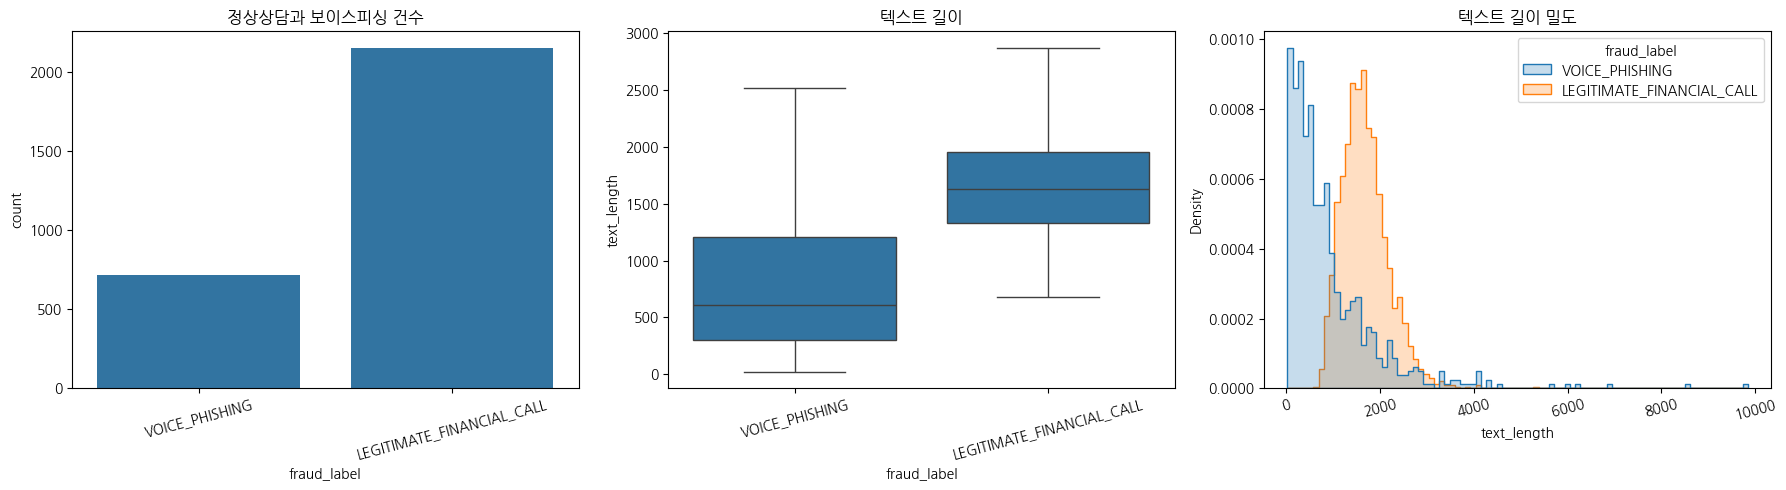

In [7]:
# 6. 정상상담과 보이스피싱 기본 비교
det=tables['fraud_detection_ml'].copy()
det['text_length']=det['model_input_text'].fillna('').str.len()
det['word_count']=det['model_input_text'].fillna('').str.split().str.len()
class_summary=det['fraud_label'].value_counts().rename_axis('구분').reset_index(name='건수')
class_summary['비율']=class_summary['건수']/class_summary['건수'].sum()
length_summary=det.groupby('fraud_label')[['text_length','word_count']].agg(['count','mean','median','std','min','max']).round(2)
display(class_summary); display(length_summary)
class_summary.to_csv(TABLE_ROOT/'04_정상사기_클래스분포.csv',index=False,encoding='utf-8-sig')
length_summary.to_csv(TABLE_ROOT/'05_정상사기_텍스트길이.csv',encoding='utf-8-sig')
fig,axes=plt.subplots(1,3,figsize=(18,5))
sns.countplot(data=det,x='fraud_label',ax=axes[0]); axes[0].set_title('정상상담과 보이스피싱 건수')
sns.boxplot(data=det,x='fraud_label',y='text_length',showfliers=False,ax=axes[1]); axes[1].set_title('텍스트 길이')
sns.histplot(data=det,x='text_length',hue='fraud_label',element='step',stat='density',common_norm=False,ax=axes[2]); axes[2].set_title('텍스트 길이 밀도')
for ax in axes: ax.tick_params(axis='x',rotation=15)
plt.tight_layout(); plt.savefig(FIGURE_ROOT/'01_정상사기_분포와길이.png',dpi=170,bbox_inches='tight'); plt.show()

fraud_label,LEGITIMATE_FINANCIAL_CALL,VOICE_PHISHING,All
source_group,,,
AIHUB_NORMAL_CALL,2151,0,2151
FSS_VOICE_PHISHING,0,717,717
All,2151,717,2868


fraud_label,LEGITIMATE_FINANCIAL_CALL,VOICE_PHISHING,All
financial_topic,,,
INSTITUTION_IMPERSONATION,0,237,237
LOAN_FRAUD,0,277,277
MIXED_UNKNOWN,0,203,203
거래내역/잔액조회,213,0,213
금융거래한도/비대면한도계좌,184,0,184
대출문의(만기/연장/조회등),702,0,702
"만기,연장/해지,수신",170,0,170
이자/연체금액,524,0,524
자동이체조회,259,0,259


fraud_label,LEGITIMATE_FINANCIAL_CALL,VOICE_PHISHING,All
original_split,,,
TRAIN,1880,0,1880
UNASSIGNED,0,717,717
VALIDATION,271,0,271
All,2151,717,2868


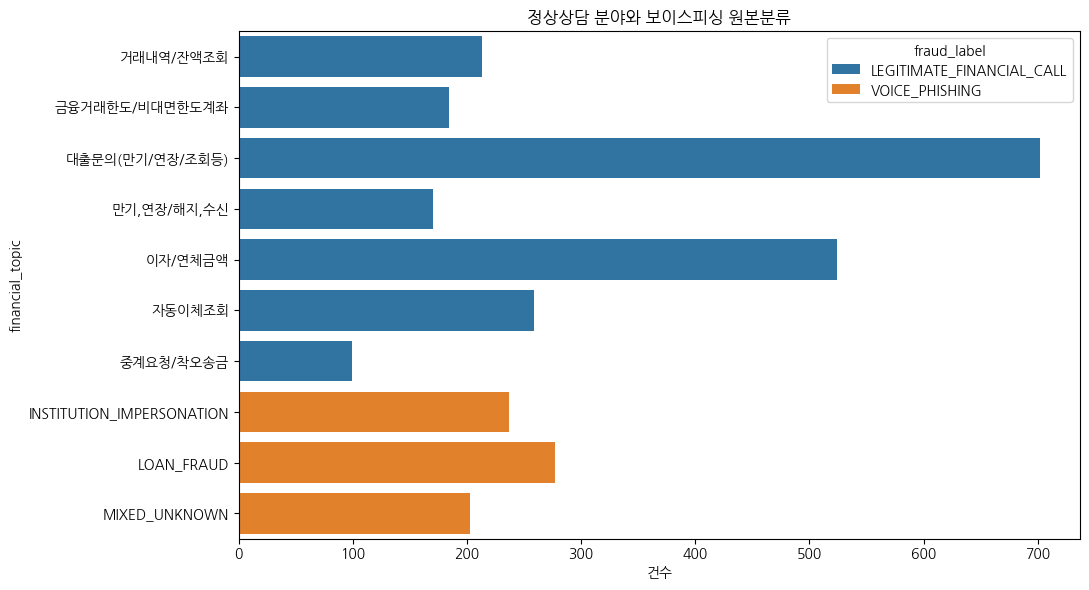

In [8]:
# 7. 출처·정상상담 분야·공식 split 확인
for col,title in [('source_group','출처'),('financial_topic','금융상담주제'),('original_split','원본분리')]:
    if col not in det: continue
    frame=pd.crosstab(det[col].fillna('MISSING'),det['fraud_label'],margins=True)
    display(frame); frame.to_csv(TABLE_ROOT/f'06_{title}_교차표.csv',encoding='utf-8-sig')
if 'financial_topic' in det:
    topic=det.groupby(['fraud_label','financial_topic']).size().reset_index(name='건수')
    plt.figure(figsize=(11,6)); sns.barplot(data=topic,y='financial_topic',x='건수',hue='fraud_label')
    plt.title('정상상담 분야와 보이스피싱 원본분류'); plt.tight_layout()
    plt.savefig(FIGURE_ROOT/'02_출처와_상담주제.png',dpi=170,bbox_inches='tight'); plt.show()

In [9]:
# 8. 클래스별 주요 단어·2-gram: 출처 문체 차이도 함께 포함될 수 있습니다.
texts=det['model_input_text'].fillna('').astype(str)
vectorizer=CountVectorizer(binary=True,ngram_range=(1,2),min_df=5,max_features=20000,token_pattern=r'(?u)\b[^\s]{2,}\b')
matrix=vectorizer.fit_transform(texts); terms=np.array(vectorizer.get_feature_names_out())
labels=det['fraud_label'].to_numpy(); classes=sorted(pd.unique(labels))
word_rows=[]
if len(classes)==2:
    rates={}
    for label in classes: rates[label]=np.asarray(matrix[labels==label].mean(axis=0)).ravel()
    diff=rates['VOICE_PHISHING']-rates['LEGITIMATE_FINANCIAL_CALL']
    for idx in diff.argsort()[-30:][::-1]: word_rows.append({'구분':'보이스피싱 상대고빈도','단어':terms[idx],'출현율차이':diff[idx]})
    for idx in diff.argsort()[:30]: word_rows.append({'구분':'정상상담 상대고빈도','단어':terms[idx],'출현율차이':diff[idx]})
word_df=pd.DataFrame(word_rows); display(word_df.head(30))
word_df.to_csv(TABLE_ROOT/'07_정상사기_상대고빈도단어.csv',index=False,encoding='utf-8-sig')

,구분,단어,출현율차이
0,보이스피싱 상대고빈도,거고요,0.244073
1,보이스피싱 상대고빈도,네네,0.243143
2,보이스피싱 상대고빈도,그러니까,0.226406
3,보이스피싱 상대고빈도,때문에,0.218038
4,보이스피싱 상대고빈도,전혀,0.216179
5,보이스피싱 상대고빈도,명의로,0.213854
6,보이스피싱 상대고빈도,본인께서,0.211994
7,보이스피싱 상대고빈도,대해서,0.210135
8,보이스피싱 상대고빈도,본인이,0.203626
9,보이스피싱 상대고빈도,거예요,0.203161


## 5. 보이스피싱 유형·사칭·요구행동

In [10]:
# 9. 사건유형·사칭·요구행동 단순 분포
type_df=tables['fraud_type_ml']; imp=tables['vp_impersonations']; actions=tables['vp_requested_actions']
type_map=type_df[['case_id','supervised_target']].drop_duplicates('case_id')
def save_count(df,col,name,top_n=None):
    if col not in df: return pd.DataFrame()
    result=df[col].fillna('MISSING').value_counts().rename_axis(col).reset_index(name='건수')
    result['비율']=result['건수']/result['건수'].sum()
    result.to_csv(TABLE_ROOT/f'{name}.csv',index=False,encoding='utf-8-sig')
    display(result.head(top_n or len(result))); return result
type_count=save_count(type_df,'supervised_target','08_보이스피싱_유형분포')
imp_group_col=next((c for c in ['impersonation_group','primary_impersonation_group'] if c in imp),None)
imp_sub_col=next((c for c in ['impersonation_subtype','claimed_org_name'] if c in imp),None)
action_col=next((c for c in ['action_type','primary_requested_action'] if c in actions),None)
if imp_group_col: save_count(imp,imp_group_col,'09_사칭대분류_분포',TOP_N)
if imp_sub_col: save_count(imp,imp_sub_col,'10_사칭세부유형_분포',TOP_N)
if action_col: save_count(actions,action_col,'11_요구행동_분포',TOP_N)

,supervised_target,건수,비율
0,LOAN_FRAUD,284,0.523985
1,INSTITUTION_IMPERSONATION,258,0.476015


,impersonation_group,건수,비율
0,FINANCIAL_INSTITUTION,1068,0.615562
1,PUBLIC_AGENCY,542,0.312392
2,ACQUAINTANCE,55,0.031700
3,FAMILY,30,0.017291
4,DELIVERY_LOGISTICS,23,0.013256
5,TELECOM_COMPANY,13,0.007493
6,EMPLOYER_RECRUITER,4,0.002305


,impersonation_subtype,건수,비율
0,BANK,620,0.357349
1,PROSECUTION,339,0.195389
2,CARD_COMPANY,257,0.148127
3,POLICE,133,0.076657
4,LOAN_COMPANY,101,0.058213
5,PERSONAL_CONTACT,50,0.028818
6,FSS,42,0.024207
7,CAPITAL_COMPANY,40,0.023055
8,SAVINGS_BANK,39,0.022478
9,KIDNAPPING_CLAIM,30,0.017291


,action_type,건수,비율
0,WITHDRAW_CASH,101,0.217204
1,TRANSFER_MONEY,59,0.126882
2,DISCLOSE_ACCOUNT,49,0.105376
3,DISCLOSE_ID_NUMBER,37,0.079570
4,REPAY_LOAN,31,0.066667
5,PAY_FEE,27,0.058065
6,DISCLOSE_CARD,26,0.055914
7,AVOID_OUTSIDE_CONTACT,25,0.053763
8,VISIT_BANK,20,0.043011
9,DISCLOSE_PASSWORD,20,0.043011


,구분,단어,출현율차이
4,보이스피싱 상대고빈도,전혀,0.216179
5,보이스피싱 상대고빈도,명의로,0.213854
12,보이스피싱 상대고빈도,사건,0.192934
18,보이스피싱 상대고빈도,불법,0.154812
19,보이스피싱 상대고빈도,현장에서,0.154812
21,보이스피싱 상대고빈도,연락을,0.144584
23,보이스피싱 상대고빈도,통장이,0.134821
28,보이스피싱 상대고빈도,피해자,0.115760
29,보이스피싱 상대고빈도,조사를,0.113436


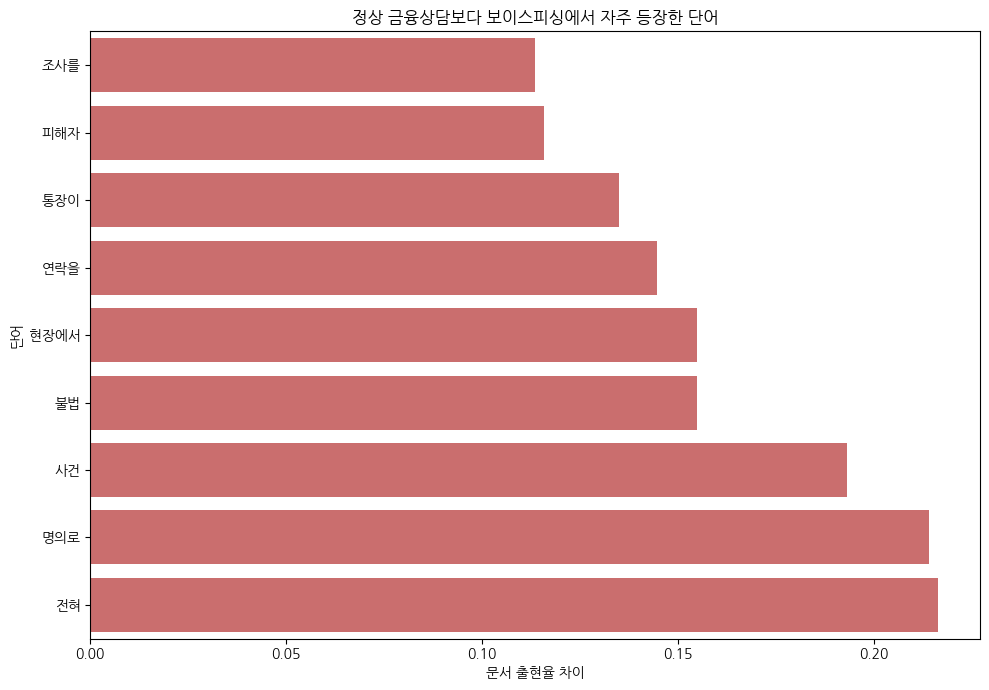

,의미범주,단어수,출현율차이_합계,대표단어
2,수사·범죄 서사,5,0.731753,"사건, 불법, 현장에서, 피해자, 조사를"
1,기타,1,0.216179,전혀
3,신원·명의 확인,1,0.213854,명의로
4,행동통제·연락,1,0.144584,연락을
0,금융수단·계좌,1,0.134821,통장이


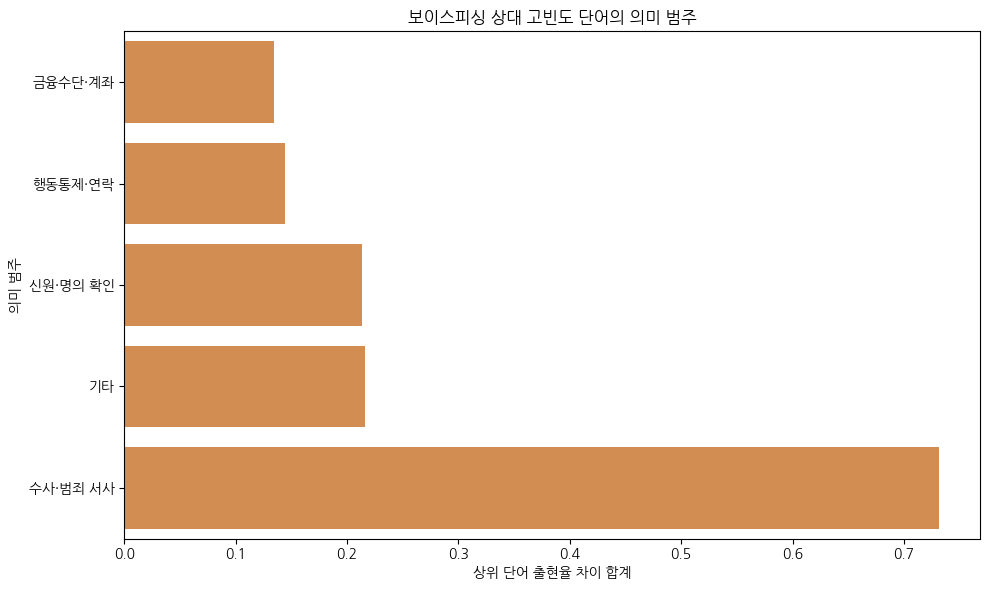

,2그램,보이스피싱_출현율,정상상담_출현율,출현율차이
8338,본인 명의로,0.107392,0.000465,0.106927
8342,본인 앞으로,0.093445,0.000000,0.093445
12263,연락을 드린,0.090656,0.003719,0.086936
16166,저희 쪽으로,0.066946,0.006509,0.060437
1066,같은 경우는,0.065551,0.013947,0.051604
7329,받고 통장을,0.048815,0.000000,0.048815
5023,돈을 받고,0.047420,0.000000,0.047420
1069,같은 경우에는,0.055788,0.013482,0.042306
13753,이번 사건에,0.041841,0.000000,0.041841
20877,현장에서 대량의,0.037657,0.000000,0.037657


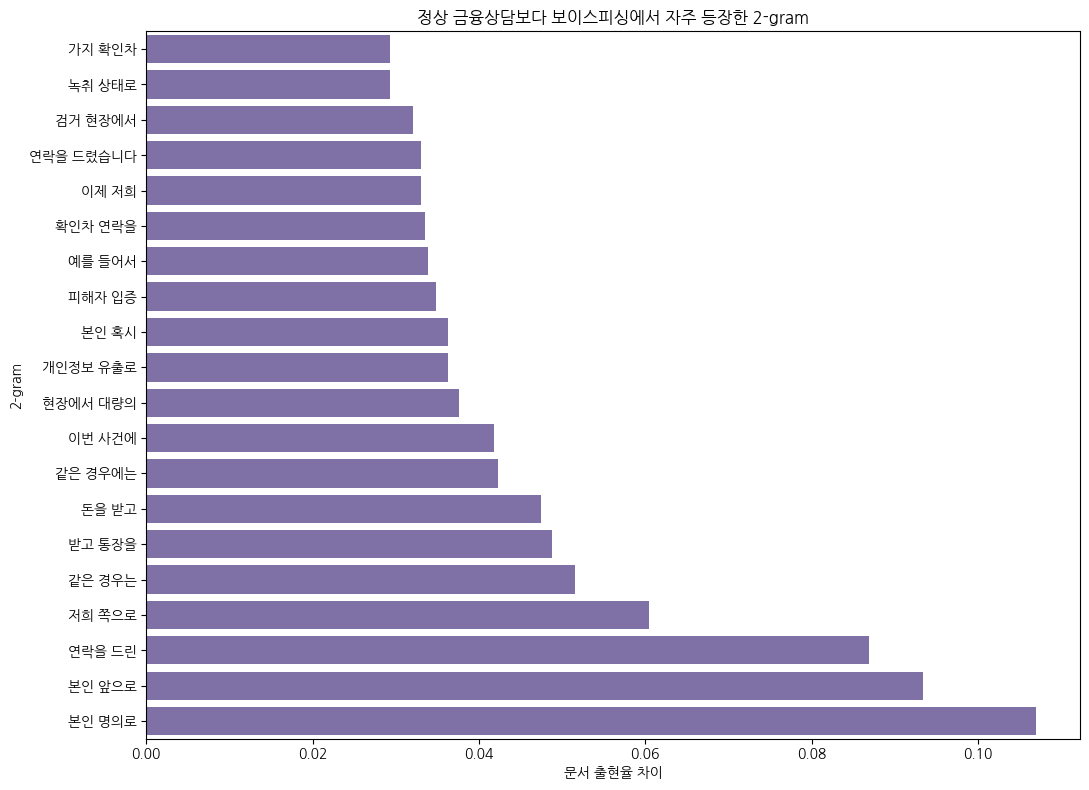

의미 단어·범주·2-gram 분석 완료


In [20]:
# 의미 있는 단어·2-gram·의미 범주 분석

# 1. 분석에서 제외할 구어체·불용어
stopwords = {
    '거고요', '네네', '그러니까', '때문에', '대해서',
    '거예요', '겁니다', '그런', '저희가', '이런',
    '아니', '이렇게', '해서', '일단은', '쪽에서',
    '건데', '돼요', '여보세요', '본인이', '본인께서',
    '그리고', '그런데', '그러면', '그래서', '그냥',
    '제가', '지금', '일단'
}

# 2. 의미 있는 보이스피싱 상대 고빈도 단어
meaningful_word_df = word_df[
    (word_df['구분'] == '보이스피싱 상대고빈도')
    & (~word_df['단어'].isin(stopwords))
    & (word_df['단어'].str.len() >= 2)
].copy()

meaningful_word_df = meaningful_word_df.nlargest(
    20,
    '출현율차이'
)

display(meaningful_word_df)

meaningful_word_df.to_csv(
    TABLE_ROOT / '08_보이스피싱_의미단어.csv',
    index=False,
    encoding='utf-8-sig'
)

# 3. 의미 단어 막대그래프
plot_word_df = meaningful_word_df.sort_values('출현율차이')

plt.figure(figsize=(10, 7))

sns.barplot(
    data=plot_word_df,
    x='출현율차이',
    y='단어',
    color='#d95f5f'
)

plt.title('정상 금융상담보다 보이스피싱에서 자주 등장한 단어')
plt.xlabel('문서 출현율 차이')
plt.ylabel('단어')
plt.tight_layout()

plt.savefig(
    FIGURE_ROOT / '11_보이스피싱_의미단어.png',
    dpi=170,
    bbox_inches='tight'
)

plt.show()


# 4. 의미 범주 분류
category_patterns = {
    '수사·범죄 서사': (
        r'사건|불법|범죄|피해자|조사|수사|'
        r'현장|검찰|검사|경찰|수사관|체포|구속'
    ),
    '신원·명의 확인': (
        r'명의|본인|신분|주민|개인정보|생년월일'
    ),
    '금융수단·계좌': (
        r'통장|계좌|은행|카드|잔액|송금|이체|입금'
    ),
    '행동통제·연락': (
        r'연락|전화|끊지|말하지|비밀|'
        r'하세요|하셔야|따라'
    ),
    '금전요구': (
        r'돈|금액|수수료|세금|보증금|'
        r'공탁금|납부|현금'
    ),
    '긴급성·위협': (
        r'긴급|즉시|빨리|당장|위험|'
        r'처벌|압류|고소|고발'
    ),
    '이익·혜택 제안': (
        r'대출|승인|환급|지원금|혜택|저금리'
    )
}


def classify_word_category(word):
    for category, pattern in category_patterns.items():
        if re.search(pattern, str(word)):
            return category
    return '기타'


meaningful_word_df['의미범주'] = (
    meaningful_word_df['단어']
    .map(classify_word_category)
)

category_summary_df = (
    meaningful_word_df
    .groupby('의미범주', as_index=False)
    .agg(
        단어수=('단어', 'count'),
        출현율차이_합계=('출현율차이', 'sum'),
        대표단어=(
            '단어',
            lambda values: ', '.join(values.head(5))
        )
    )
    .sort_values(
        '출현율차이_합계',
        ascending=False
    )
)

display(category_summary_df)

category_summary_df.to_csv(
    TABLE_ROOT / '09_보이스피싱_단어의미범주.csv',
    index=False,
    encoding='utf-8-sig'
)

# 5. 의미 범주 그래프
plot_category_df = category_summary_df.sort_values(
    '출현율차이_합계'
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_category_df,
    x='출현율차이_합계',
    y='의미범주',
    color='#e78b3e'
)

plt.title('보이스피싱 상대 고빈도 단어의 의미 범주')
plt.xlabel('상위 단어 출현율 차이 합계')
plt.ylabel('의미 범주')
plt.tight_layout()

plt.savefig(
    FIGURE_ROOT / '12_보이스피싱_단어의미범주.png',
    dpi=170,
    bbox_inches='tight'
)

plt.show()


# 6. 의미 있는 2-gram 다시 계산
bigram_vectorizer = CountVectorizer(
    binary=True,
    ngram_range=(2, 2),
    min_df=5,
    max_features=30000,
    token_pattern=r'(?u)\b[^\s]{2,}\b'
)

bigram_matrix = bigram_vectorizer.fit_transform(
    det['model_input_text'].fillna('').astype(str)
)

bigram_terms = np.array(
    bigram_vectorizer.get_feature_names_out()
)

labels = det['fraud_label'].to_numpy()

fraud_rate = np.asarray(
    bigram_matrix[labels == 'VOICE_PHISHING']
    .mean(axis=0)
).ravel()

normal_rate = np.asarray(
    bigram_matrix[
        labels == 'LEGITIMATE_FINANCIAL_CALL'
    ]
    .mean(axis=0)
).ravel()

bigram_difference = fraud_rate - normal_rate

bigram_df = pd.DataFrame({
    '2그램': bigram_terms,
    '보이스피싱_출현율': fraud_rate,
    '정상상담_출현율': normal_rate,
    '출현율차이': bigram_difference
})

# 불용어가 포함된 2-gram 제외
bigram_df['불용어포함'] = bigram_df['2그램'].map(
    lambda value: any(
        token in stopwords
        for token in str(value).split()
    )
)

meaningful_bigram_df = (
    bigram_df[
        (~bigram_df['불용어포함'])
        & (bigram_df['출현율차이'] > 0)
    ]
    .nlargest(20, '출현율차이')
    .drop(columns='불용어포함')
)

display(meaningful_bigram_df)

meaningful_bigram_df.to_csv(
    TABLE_ROOT / '10_보이스피싱_의미있는_2그램.csv',
    index=False,
    encoding='utf-8-sig'
)

# 7. 2-gram 그래프
plot_bigram_df = meaningful_bigram_df.sort_values(
    '출현율차이'
)

plt.figure(figsize=(11, 8))

sns.barplot(
    data=plot_bigram_df,
    x='출현율차이',
    y='2그램',
    color='#7b68ae'
)

plt.title('정상 금융상담보다 보이스피싱에서 자주 등장한 2-gram')
plt.xlabel('문서 출현율 차이')
plt.ylabel('2-gram')
plt.tight_layout()

plt.savefig(
    FIGURE_ROOT / '13_보이스피싱_의미있는_2그램.png',
    dpi=170,
    bbox_inches='tight'
)

plt.show()

print('의미 단어·범주·2-gram 분석 완료')

impersonation_subtype,BANK,BUSINESS_CONTACT,CAPITAL_COMPANY,CARD_COMPANY,COURT,DELIVERY_COMPANY,FINANCIAL_ASSOCIATION,FSS,KIDNAPPING_CLAIM,LOAN_COMPANY,PERSONAL_CONTACT,POLICE,POST_OFFICE,PROSECUTION,RECRUITER,SAVINGS_BANK,TAX_AUTHORITY,TELECOM
supervised_target,,,,,,,,,,,,,,,,,,
INSTITUTION_IMPERSONATION,239,2,1,105,5,2,0,14,11,48,10,99,4,147,0,0,0,4
LOAN_FRAUD,204,1,37,93,6,7,8,11,16,29,18,21,9,5,3,35,2,4


impersonation_subtype,BANK,BUSINESS_CONTACT,CAPITAL_COMPANY,CARD_COMPANY,COURT,DELIVERY_COMPANY,FINANCIAL_ASSOCIATION,FSS,KIDNAPPING_CLAIM,LOAN_COMPANY,PERSONAL_CONTACT,POLICE,POST_OFFICE,PROSECUTION,RECRUITER,SAVINGS_BANK,TAX_AUTHORITY,TELECOM
supervised_target,,,,,,,,,,,,,,,,,,
INSTITUTION_IMPERSONATION,0.3459,0.0029,0.0014,0.1520,0.0072,0.0029,0.0000,0.0203,0.0159,0.0695,0.0145,0.1433,0.0058,0.2127,0.0000,0.0000,0.0000,0.0058
LOAN_FRAUD,0.4008,0.0020,0.0727,0.1827,0.0118,0.0138,0.0157,0.0216,0.0314,0.0570,0.0354,0.0413,0.0177,0.0098,0.0059,0.0688,0.0039,0.0079


action_type,AVOID_OUTSIDE_CONTACT,DELIVER_CASH,DISCLOSE_ACCOUNT,DISCLOSE_CARD,DISCLOSE_ID_NUMBER,DISCLOSE_OTP,DISCLOSE_PASSWORD,HAND_OVER_CARD,INSTALL_APP,KEEP_CALL_CONNECTED,PAY_FEE,RENT_ACCOUNT,REPAY_LOAN,SEND_ID_COPY,SEND_TRANSACTION_HISTORY,TRANSFER_MONEY,VISIT_ATM,VISIT_BANK,WITHDRAW_CASH
supervised_target,,,,,,,,,,,,,,,,,,,
INSTITUTION_IMPERSONATION,5,0,14,12,8,7,4,2,0,10,0,2,1,2,4,14,0,12,29
LOAN_FRAUD,9,3,18,2,21,3,5,11,1,6,25,2,24,5,2,39,4,6,57


action_type,AVOID_OUTSIDE_CONTACT,DELIVER_CASH,DISCLOSE_ACCOUNT,DISCLOSE_CARD,DISCLOSE_ID_NUMBER,DISCLOSE_OTP,DISCLOSE_PASSWORD,HAND_OVER_CARD,INSTALL_APP,KEEP_CALL_CONNECTED,PAY_FEE,RENT_ACCOUNT,REPAY_LOAN,SEND_ID_COPY,SEND_TRANSACTION_HISTORY,TRANSFER_MONEY,VISIT_ATM,VISIT_BANK,WITHDRAW_CASH
supervised_target,,,,,,,,,,,,,,,,,,,
INSTITUTION_IMPERSONATION,0.0397,0.0000,0.1111,0.0952,0.0635,0.0556,0.0317,0.0159,0.0000,0.0794,0.0000,0.0159,0.0079,0.0159,0.0317,0.1111,0.0000,0.0952,0.2302
LOAN_FRAUD,0.0370,0.0123,0.0741,0.0082,0.0864,0.0123,0.0206,0.0453,0.0041,0.0247,0.1029,0.0082,0.0988,0.0206,0.0082,0.1605,0.0165,0.0247,0.2346


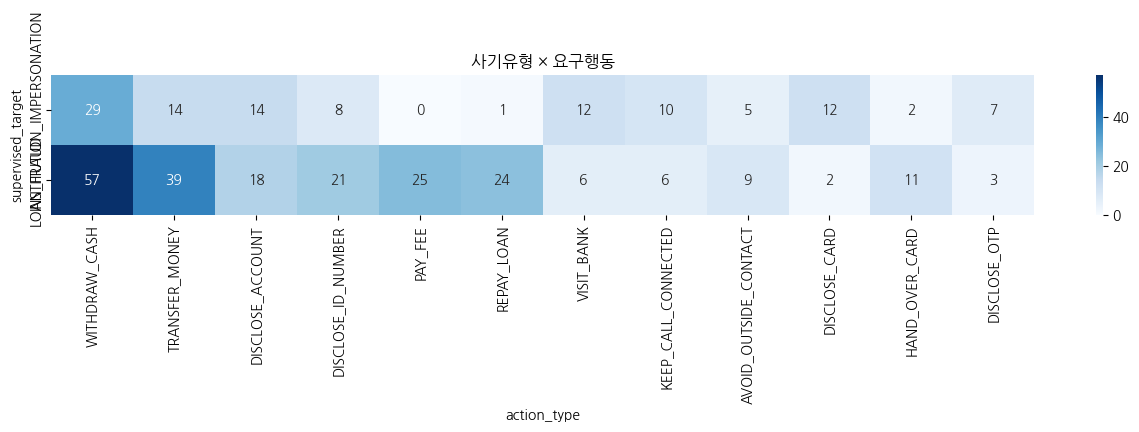

In [11]:
# 10. 사기유형 × 사칭기관, 사기유형 × 요구행동
def event_crosstab(event_df,event_col,filename):
    if event_col is None or event_df.empty: return pd.DataFrame()
    merged=event_df.merge(type_map,on='case_id',how='inner')
    count=pd.crosstab(merged['supervised_target'],merged[event_col])
    ratio=pd.crosstab(merged['supervised_target'],merged[event_col],normalize='index').round(4)
    count.to_csv(TABLE_ROOT/f'{filename}_건수.csv',encoding='utf-8-sig')
    ratio.to_csv(TABLE_ROOT/f'{filename}_행비율.csv',encoding='utf-8-sig')
    display(count); display(ratio); return count
imp_cross=event_crosstab(imp,imp_sub_col,'12_사기유형_사칭세부유형')
action_cross=event_crosstab(actions,action_col,'13_사기유형_요구행동')
if not action_cross.empty:
    top=action_cross.sum().nlargest(min(12,len(action_cross.columns))).index
    plt.figure(figsize=(13,4)); sns.heatmap(action_cross[top],annot=True,fmt='g',cmap='Blues')
    plt.title('사기유형 × 요구행동'); plt.tight_layout(); plt.savefig(FIGURE_ROOT/'03_사기유형_요구행동.png',dpi=170); plt.show()

impersonation_subtype,은행,거래처,캐피탈,카드회사,법원,택배회사,금융협회,금융감독원,납치 주장,대출회사,지인·가족,경찰,우체국,검찰,채용담당자,저축은행,세무기관,통신회사
supervised_target,,,,,,,,,,,,,,,,,,
수사기관 사칭형,25.98,0.46,0.23,17.24,0.92,0.46,0.00,2.99,2.07,9.89,2.07,14.71,0.92,21.15,0.00,0.00,0.00,0.92
대출사기형,34.37,0.28,8.73,14.93,1.41,1.41,1.97,3.10,3.94,7.89,4.79,3.66,2.25,1.13,0.85,7.61,0.56,1.13


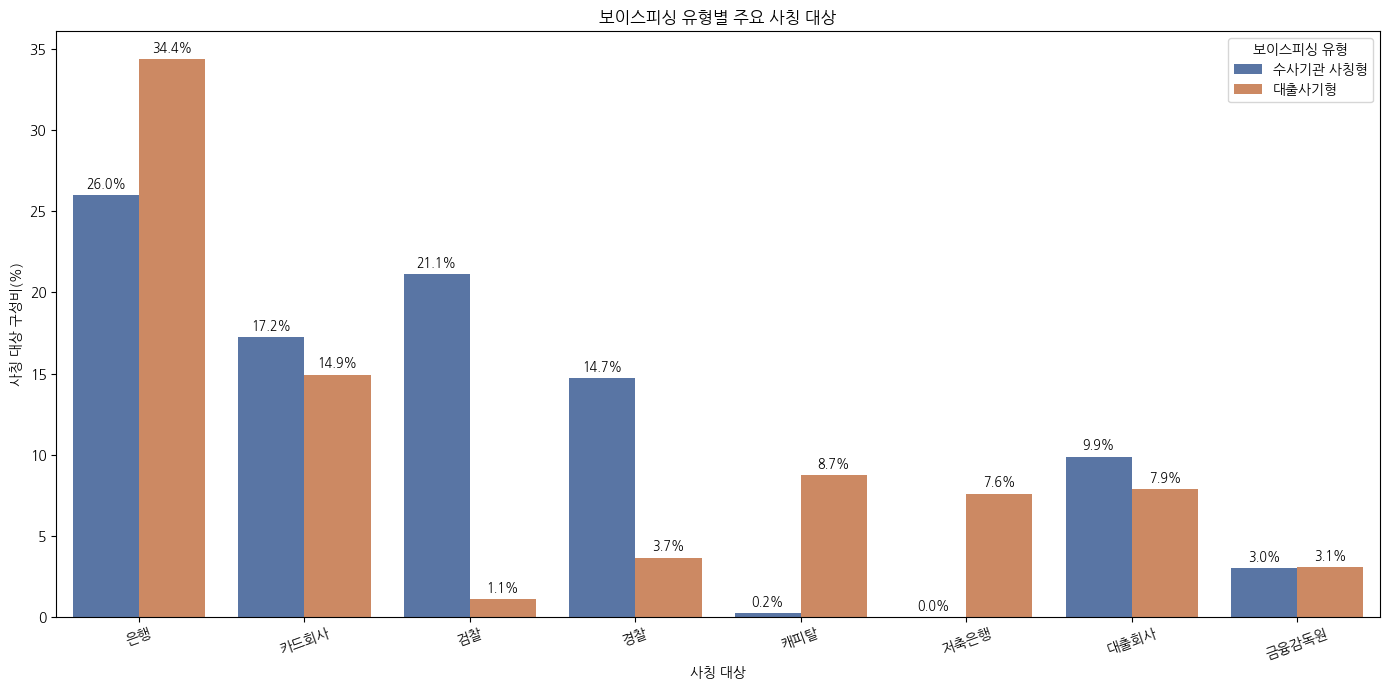

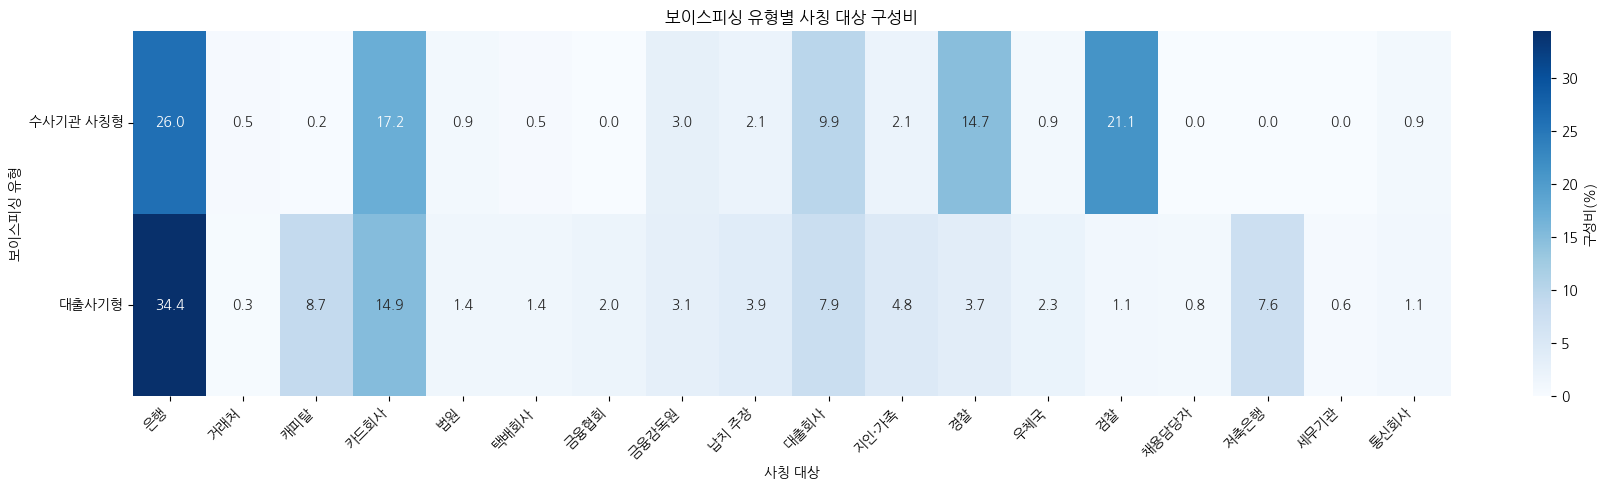

사칭 대상 그래프 저장 완료


In [21]:
# 사기유형별 사칭 대상 구성비 시각화

# 동일 사건에서 동일 기관이 여러 번 추출된 경우 한 번만 계산
impersonation_case_df = (
    imp[['case_id', imp_sub_col]]
    .dropna()
    .drop_duplicates(['case_id', imp_sub_col])
    .merge(
        type_map,
        on='case_id',
        how='inner'
    )
)

# 사칭 대상 건수
impersonation_count_df = pd.crosstab(
    impersonation_case_df['supervised_target'],
    impersonation_case_df[imp_sub_col]
)

# 각 사기유형 안에서의 구성비(%)
impersonation_ratio_df = pd.crosstab(
    impersonation_case_df['supervised_target'],
    impersonation_case_df[imp_sub_col],
    normalize='index'
) * 100

# 한글 이름
impersonation_name_map = {
    'BANK': '은행',
    'BUSINESS_CONTACT': '거래처',
    'CAPITAL_COMPANY': '캐피탈',
    'CARD_COMPANY': '카드회사',
    'COURT': '법원',
    'DELIVERY_COMPANY': '택배회사',
    'FINANCIAL_ASSOCIATION': '금융협회',
    'FSS': '금융감독원',
    'KIDNAPPING_CLAIM': '납치 주장',
    'LOAN_COMPANY': '대출회사',
    'PERSONAL_CONTACT': '지인·가족',
    'POLICE': '경찰',
    'POST_OFFICE': '우체국',
    'PROSECUTION': '검찰',
    'RECRUITER': '채용담당자',
    'SAVINGS_BANK': '저축은행',
    'TAX_AUTHORITY': '세무기관',
    'TELECOM': '통신회사'
}

fraud_type_name_map = {
    'INSTITUTION_IMPERSONATION': '수사기관 사칭형',
    'LOAN_FRAUD': '대출사기형'
}

impersonation_ratio_ko_df = (
    impersonation_ratio_df
    .rename(
        index=fraud_type_name_map,
        columns=impersonation_name_map
    )
)

display(impersonation_ratio_ko_df.round(2))

# 결과 저장
impersonation_count_df.to_csv(
    TABLE_ROOT / '사기유형별_사칭대상_건수.csv',
    encoding='utf-8-sig'
)

impersonation_ratio_ko_df.to_csv(
    TABLE_ROOT / '사기유형별_사칭대상_구성비.csv',
    encoding='utf-8-sig'
)


# 1. 주요 사칭 대상 막대그래프
major_impersonations = [
    '은행',
    '카드회사',
    '검찰',
    '경찰',
    '캐피탈',
    '저축은행',
    '대출회사',
    '금융감독원'
]

available_impersonations = [
    column
    for column in major_impersonations
    if column in impersonation_ratio_ko_df.columns
]

bar_df = (
    impersonation_ratio_ko_df[available_impersonations]
    .reset_index()
    .rename(columns={'supervised_target': '사기유형'})
    .melt(
        id_vars='사기유형',
        var_name='사칭대상',
        value_name='구성비'
    )
)

plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=bar_df,
    x='사칭대상',
    y='구성비',
    hue='사기유형',
    palette=['#4c72b0', '#dd8452']
)

plt.title('보이스피싱 유형별 주요 사칭 대상')
plt.xlabel('사칭 대상')
plt.ylabel('사칭 대상 구성비(%)')
plt.xticks(rotation=20)
plt.legend(title='보이스피싱 유형')

# 막대 위에 비율 표시
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3,
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    FIGURE_ROOT / '사기유형별_주요사칭대상_막대그래프.png',
    dpi=170,
    bbox_inches='tight'
)

plt.show()


# 2. 전체 사칭 대상 히트맵
plt.figure(figsize=(18, 5))

sns.heatmap(
    impersonation_ratio_ko_df,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    cbar_kws={'label': '구성비(%)'}
)

plt.title('보이스피싱 유형별 사칭 대상 구성비')
plt.xlabel('사칭 대상')
plt.ylabel('보이스피싱 유형')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(
    FIGURE_ROOT / '사기유형별_사칭대상_히트맵.png',
    dpi=170,
    bbox_inches='tight'
)

plt.show()

print('사칭 대상 그래프 저장 완료')

In [22]:
# 수사기관형에서 BANK로 추출된 사례 확인

bank_cases = (
    imp[
        imp[imp_sub_col].eq('BANK')
    ]
    .merge(
        type_map,
        on='case_id',
        how='inner'
    )
)

bank_cases = bank_cases[
    bank_cases['supervised_target']
    .eq('INSTITUTION_IMPERSONATION')
]

check_columns = [
    column for column in [
        'case_id',
        'impersonation_group',
        'impersonation_subtype',
        'claimed_org_name',
        'claimed_role_title',
        'is_primary_impersonation',
        'evidence_text'
    ]
    if column in bank_cases.columns
]

display(
    bank_cases[check_columns]
    .sort_values(
        'is_primary_impersonation',
        ascending=False
    )
    .head(50)
)

,case_id,impersonation_group,impersonation_subtype,is_primary_impersonation,evidence_text
378,vp_36402_case_001,FINANCIAL_INSTITUTION,BANK,True,저희들이 통장들에 해당 은행처 대조를 해봤거든요.
229,vp_36347_case_001,FINANCIAL_INSTITUTION,BANK,True,개인 명의로 된 기업은행 통장과 하나은행 통장 계좌가 불법 통장으로 사용되고 있는 ...
300,vp_36369_case_005,FINANCIAL_INSTITUTION,BANK,True,그리고 지금 대포통장까지 나온 걸 봐서는 차후에 범죄나들이 이 X이 명의로 또 다른...
319,vp_36374_case_001,FINANCIAL_INSTITUTION,BANK,True,어느 은행입니까?
293,vp_36368_case_002,FINANCIAL_INSTITUTION,BANK,True,지난 2014년 10월 13일 영등포 물레지점에서 농협 국민은행 이토 통장을 직접 ...
417,vp_36417_case_003,FINANCIAL_INSTITUTION,BANK,True,저는 그쪽 통장 안 쓰지는 않는데요 그 은행 통장을.
236,vp_36349_case_002,FINANCIAL_INSTITUTION,BANK,True,은행 직원도
316,vp_36372_case_001,FINANCIAL_INSTITUTION,BANK,True,"예. 이번 사건에 대해서 범죄자들을 체포를 했는데 범죄자들의 추가적인 공범, 은행사..."
354,vp_36390_case_001,FINANCIAL_INSTITUTION,BANK,True,그들이 그 은행권을 통해 저사를 해봤는데 그 X이 명의로 된 그 국민은행과 농협계좌...
269,vp_36361_case_001,FINANCIAL_INSTITUTION,BANK,True,이 명의로 된 이 하나은행과 농협 계좌를 압수했는데요.


In [23]:
primary_imp = imp.copy()

if 'is_primary_impersonation' in primary_imp.columns:
    primary_imp = primary_imp[
        primary_imp['is_primary_impersonation'].eq(True)
    ]

primary_imp = primary_imp.merge(
    type_map,
    on='case_id',
    how='inner'
)

primary_ratio = pd.crosstab(
    primary_imp['supervised_target'],
    primary_imp[imp_sub_col],
    normalize='index'
) * 100

display(primary_ratio.round(1))

impersonation_subtype,BANK,BUSINESS_CONTACT,CAPITAL_COMPANY,CARD_COMPANY,COURT,FINANCIAL_ASSOCIATION,FSS,KIDNAPPING_CLAIM,LOAN_COMPANY,PERSONAL_CONTACT,POLICE,POST_OFFICE,PROSECUTION,SAVINGS_BANK,TELECOM
supervised_target,,,,,,,,,,,,,,,
INSTITUTION_IMPERSONATION,24.2,0.0,0.5,11.1,0.0,0.0,1.1,1.1,4.7,0.0,19.5,0.5,37.4,0.0,0.0
LOAN_FRAUD,38.5,0.5,10.7,15.0,1.1,0.5,3.2,3.7,5.3,5.3,4.3,1.1,1.6,8.0,1.1


In [27]:
# 사건 단위 사칭 대상 검토표 생성

imp_case = imp.copy()

# 숫자·문자형 정리
imp_case['mention_count'] = pd.to_numeric(
    imp_case.get('mention_count', 0),
    errors='coerce'
).fillna(0)

imp_case['first_mention_turn'] = pd.to_numeric(
    imp_case.get('first_mention_turn', 999999),
    errors='coerce'
).fillna(999999)

imp_case['extraction_confidence'] = pd.to_numeric(
    imp_case.get('extraction_confidence', 0),
    errors='coerce'
).fillna(0)

# 범인이 자신의 소속이라고 명시적으로 주장했는지
imp_case['명시적_자기사칭'] = (
    imp_case.get(
        'identity_claim_type',
        pd.Series('', index=imp_case.index)
    ).eq('CALLER_SELF_CLAIM')
    &
    imp_case.get(
        'evidence_role',
        pd.Series('', index=imp_case.index)
    ).eq('OFFENDER')
)

# 직책이 함께 등장했는지
role_title = imp_case.get(
    'claimed_role_title_normalized',
    pd.Series('', index=imp_case.index)
).fillna('').astype(str)

imp_case['직책존재'] = role_title.str.strip().ne('')

case_rows = []

for case_id, group in imp_case.groupby('case_id'):

    group = group.sort_values('first_mention_turn')

    # 사건에서 가장 먼저 등장한 사칭기관
    access_subtype = (
        group.iloc[0]['impersonation_subtype']
        if len(group)
        else 'UNKNOWN'
    )

    # 범인이 명시적으로 자기 소속이라고 주장한 후보
    explicit_group = group[
        group['명시적_자기사칭']
    ].copy()

    if len(explicit_group):

        # 반복 횟수, 직책, 신뢰도가 높은 후보를 우선
        explicit_group = explicit_group.sort_values(
            [
                'mention_count',
                '직책존재',
                'extraction_confidence',
                'first_mention_turn'
            ],
            ascending=[False, False, False, True]
        )

        primary_row = explicit_group.iloc[0]
        primary_subtype = primary_row[
            'impersonation_subtype'
        ]
        primary_evidence = primary_row.get(
            'evidence_text',
            ''
        )
        primary_confidence = primary_row[
            'extraction_confidence'
        ]

    else:
        # 명시적 자기소개가 없으면 억지로 확정하지 않음
        primary_subtype = 'UNKNOWN'
        primary_evidence = ''
        primary_confidence = 0.0

    all_subtypes = list(
        dict.fromkeys(
            group['impersonation_subtype']
            .dropna()
            .astype(str)
            .tolist()
        )
    )

    secondary_subtypes = [
        subtype
        for subtype in all_subtypes
        if subtype != primary_subtype
    ]

    explicit_subtypes = list(
        dict.fromkeys(
            explicit_group['impersonation_subtype']
            .dropna()
            .astype(str)
            .tolist()
        )
    )

    evidence_list = [
        str(value)
        for value in group.get(
            'evidence_text',
            pd.Series(dtype=str)
        ).dropna().unique()
        if str(value).strip()
    ]

    case_rows.append({
        'case_id': case_id,
        '접근사칭기관': access_subtype,
        '자동_주요사칭기관': primary_subtype,
        '보조사칭기관_목록': ' | '.join(
            secondary_subtypes
        ),
        '전체사칭후보_목록': ' | '.join(
            all_subtypes
        ),
        '명시적사칭기관_목록': ' | '.join(
            explicit_subtypes
        ),
        '사칭기관수': len(all_subtypes),
        '다중사칭여부': len(all_subtypes) > 1,
        '자동판단신뢰도': primary_confidence,
        '주요사칭_근거문장': primary_evidence,
        '전체사칭_근거문장': ' || '.join(
            evidence_list[:10]
        ),
        '검수필요여부': (
            primary_subtype == 'UNKNOWN'
            or len(explicit_subtypes) > 1
        ),
        '검수_주요사칭기관': '',
        '검수메모': ''
    })

case_impersonation_df = pd.DataFrame(case_rows)

# 원본 사기유형 연결
case_impersonation_df = case_impersonation_df.merge(
    type_map,
    on='case_id',
    how='left'
)

# 사건 전체 범인 대화 연결
case_text_column = next(
    (
        column
        for column in [
            'raw_offender_text',
            'normalized_offender_text',
            'raw_full_text',
            'normalized_full_text'
        ]
        if column in cases.columns
    ),
    None
)

if case_text_column:
    case_text_df = (
        cases[['case_id', case_text_column]]
        .drop_duplicates('case_id')
        .rename(
            columns={
                case_text_column: '사건전체_범인대화'
            }
        )
    )

    case_impersonation_df = (
        case_impersonation_df.merge(
            case_text_df,
            on='case_id',
            how='left'
        )
    )

# 사람이 보기 좋은 순서
front_columns = [
    'case_id',
    'supervised_target',
    '접근사칭기관',
    '자동_주요사칭기관',
    '명시적사칭기관_목록',
    '보조사칭기관_목록',
    '전체사칭후보_목록',
    '다중사칭여부',
    '자동판단신뢰도',
    '주요사칭_근거문장',
    '전체사칭_근거문장',
    '사건전체_범인대화',
    '검수필요여부',
    '검수_주요사칭기관',
    '검수메모'
]

front_columns = [
    column
    for column in front_columns
    if column in case_impersonation_df.columns
]

case_impersonation_df = case_impersonation_df[
    front_columns
]

display(case_impersonation_df.head(20))

case_impersonation_df.to_csv(
    TABLE_ROOT / '사건단위_사칭대상_검토표.csv',
    index=False,
    encoding='utf-8-sig'
)

print(
    '사건 수:',
    len(case_impersonation_df)
)

print(
    '검수 필요:',
    case_impersonation_df[
        '검수필요여부'
    ].sum()
)

print(
    '저장:',
    TABLE_ROOT / '사건단위_사칭대상_검토표.csv'
)

,case_id,supervised_target,접근사칭기관,자동_주요사칭기관,명시적사칭기관_목록,보조사칭기관_목록,전체사칭후보_목록,다중사칭여부,자동판단신뢰도,주요사칭_근거문장,전체사칭_근거문장,사건전체_범인대화,검수필요여부,검수_주요사칭기관,검수메모
0,vp_130761_case_001,NaN,PROSECUTION,UNKNOWN,,PROSECUTION,PROSECUTION,False,0.0,,"네, 서울중앙지검이고요. 저희 쪽에서 발표해드린 공문장 혹시 못 받으셨어요? || ...","네, 여보세요? 네, 기XX씨 본인 되십니까? 네, 서울중앙지검이고요. 저희 쪽에서...",True,,
1,vp_130762_case_001,NaN,CARD_COMPANY,UNKNOWN,,CARD_COMPANY | BANK,CARD_COMPANY | BANK,True,0.0,,O은행하고 O은행 체크카드가 발견이 됐고,그렇죠 그러니까 지금 이 사건이란 거는 본인 함부로 하는 게 아닙니다 지금 본인을 ...,True,,
2,vp_130762_case_002,NaN,BANK,PROSECUTION,PROSECUTION,BANK,BANK | PROSECUTION,True,0.7,저는 서울중앙지검 기능범죄수사일보 김태호 검사입니다,O은행이나 O은행이 연락을 한 번에 취해볼게요 || 저는 서울중앙지검 기능범죄수사일...,네 그리고 녹취 상태에서 본인께서 말씀하신 모든 부분을 이제 녹취 기록에 남길 거고...,False,,
3,vp_130764_case_001,NaN,PROSECUTION,UNKNOWN,,PROSECUTION,PROSECUTION,False,0.0,,출석 요구서를 받으시고 48시간 이내로 서울중앙지검으로 오시면 되신다고요.,피의자인지 아니면 갠 정보 유출로 인해 피해를 본 피해자인지 이 부분을 확인하려고 ...,True,,
4,vp_130767_case_001,NaN,PROSECUTION,UNKNOWN,,PROSECUTION,PROSECUTION,False,0.0,,네 그리고 제가 이제 사건 내용 설명 후에 이제 저희 검찰청 홈페이지에서,여보세요? 혹시 본인 되십니까? 저는 서울중앙지금 최진호 사무관입니다. 지금 연락드...,True,,
5,vp_130768_case_001,NaN,PROSECUTION,PROSECUTION,PROSECUTION,COURT,PROSECUTION | COURT,True,0.7,서울 남부지검입니다.,서울 남부지검입니다. || 저는 법원에 인가받은 녹취용 단말기로,서울 남부지검입니다. 그리고 제가 XX 앞으로 전화드린 이유는 다름 아니고 저희가 ...,False,,
6,vp_130778_case_001,NaN,COURT,COURT,COURT | PROSECUTION,PROSECUTION,COURT | PROSECUTION,True,0.7,연락드린 곳은 법원찰청의 이정현 사무관이라고 합니다.,"네, 수고하십니다. 법원 등기우편 관련해서 연락드렸고요. || 연락드린 곳은 법원찰...","네, 수고하십니다. 법원 등기우편 관련해서 연락드렸고요. 연락드린 곳은 법원찰청의 ...",True,,
7,vp_130780_case_001,NaN,FSS,LOAN_COMPANY,LOAN_COMPANY | BANK | FINANCIAL_ASSOCIATION,FSS | BANK | FINANCIAL_ASSOCIATION | PERSONAL_...,FSS | BANK | FINANCIAL_ASSOCIATION | PERSONAL_...,True,0.7,그냥 간단하게 지금 내 앞으로 원래 한도는 다 나와 있는데 내가 지금 지급 정지가 ...,저희가 전산 작업으로 갑자기 신용도를 상승시켰기 때문에 저희가 고객님 통장에 입금 ...,"여보세요. 네, 담당자고요. 네, 지금 통화 가능하신가요? 지금 진행 결과 나오셨고...",True,,
8,vp_130781_case_001,NaN,PROSECUTION,UNKNOWN,,PROSECUTION,PROSECUTION,False,0.0,,"지금 연락드린 곳은요, 저희는 대검찰청","네, 여보세요? 네, 수고 많으십니다, 혹시. XXX씨 본인 맞으신가요? 지금 연락...",True,,
9,vp_130783_case_001,NaN,PROSECUTION,PROSECUTION,PROSECUTION,BANK,PROSECUTION | BANK,True,0.7,그런 부분은 담당은 저희가 검사님이 계시니까요.,그런 부분은 담당은 저희가 검사님이 계시니까요. || X은행 참여계자고요. || 이...,일단 저희가 해전시간부로 본회 앞으로 금융권 준수소사를 할 건데 이걸 하는 이유는 ...,False,,


사건 수: 544
검수 필요: 397
저장: /content/drive/MyDrive/보이스피싱_분석/EDA_분석결과_v1/01_분석표/사건단위_사칭대상_검토표.csv


주요사칭기관,거래처,검찰,경찰,금융감독원,납치 주장,대출회사,은행,저축은행,카드회사,캐피탈,판단불가
사기유형,,,,,,,,,,,
대출사기형,1,2,2,2,0,1,21,4,4,4,146
수사기관 사칭형,0,61,19,2,1,1,11,0,1,0,94


주요사칭기관,거래처,검찰,경찰,금융감독원,납치 주장,대출회사,은행,저축은행,카드회사,캐피탈,판단불가
사기유형,,,,,,,,,,,
대출사기형,0.5,1.1,1.1,1.1,0.0,0.5,11.2,2.1,2.1,2.1,78.1
수사기관 사칭형,0.0,32.1,10.0,1.1,0.5,0.5,5.8,0.0,0.5,0.0,49.5


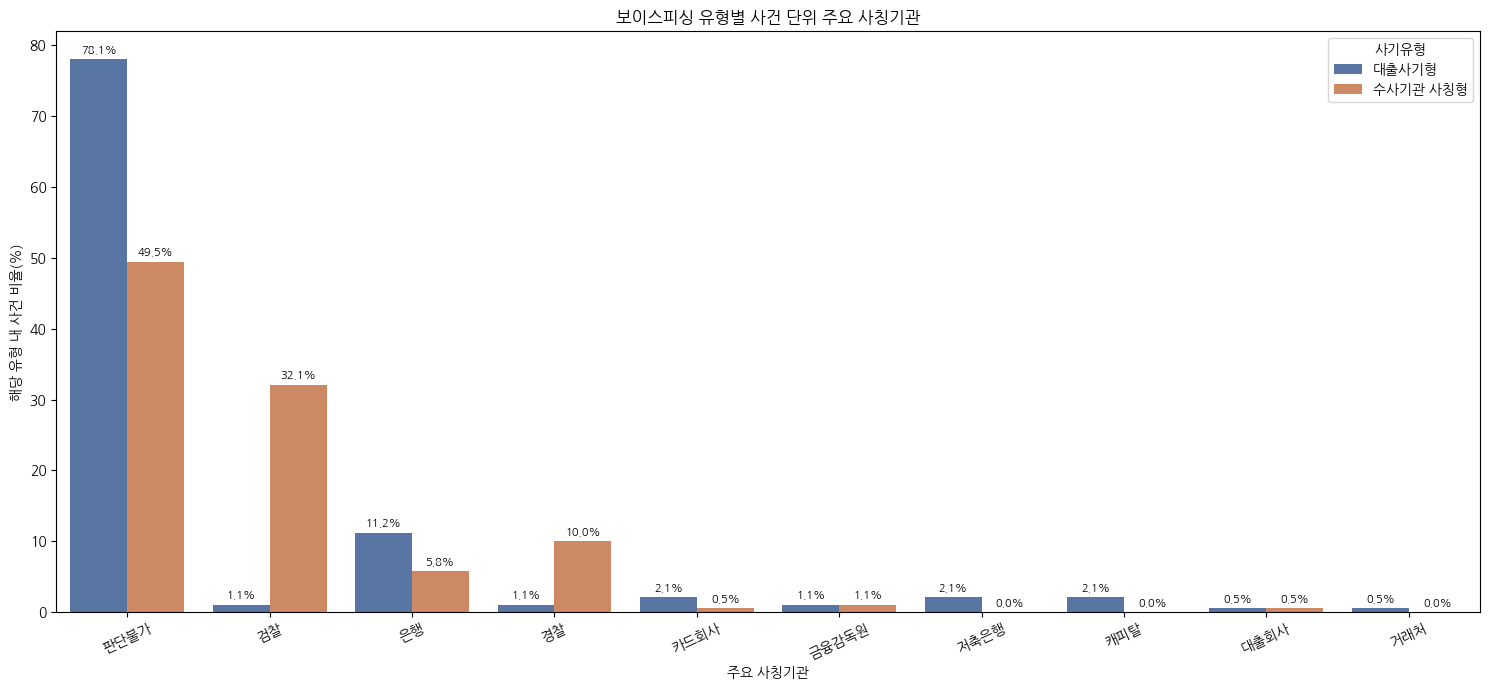

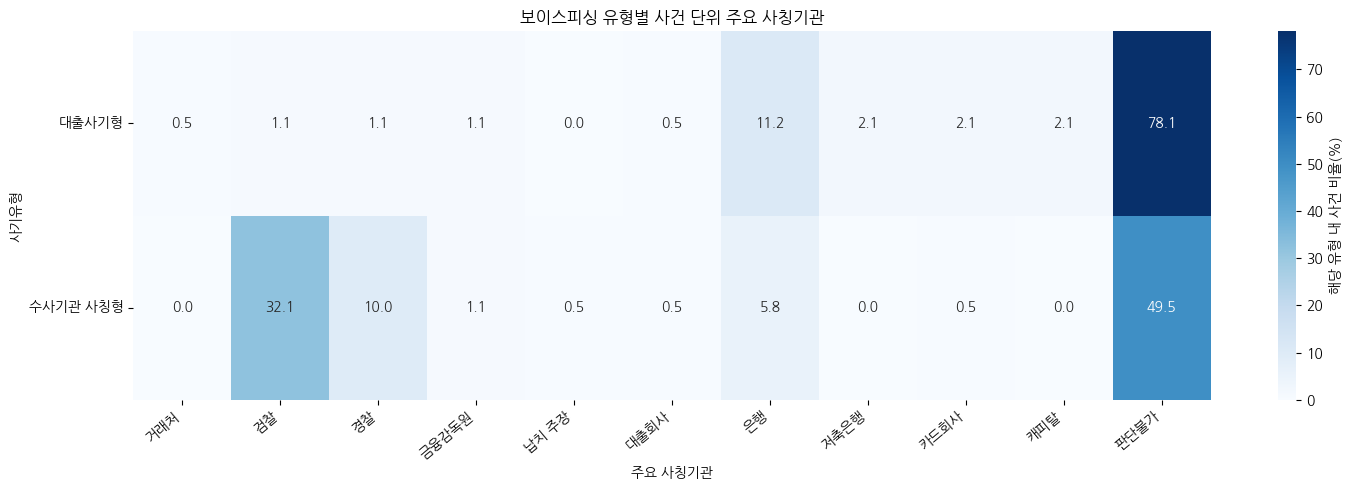

주요사칭기관,판단불가,검찰,은행,경찰,대출회사,금융감독원,카드회사,캐피탈,저축은행,거래처
접근사칭기관_한글,,,,,,,,,,
은행,111,16,31,5,0,2,2,0,0,0
검찰,46,86,4,0,0,0,2,0,0,0
카드회사,55,10,4,2,0,0,2,0,0,0
경찰,25,2,0,13,0,0,0,0,0,0
대출회사,21,4,2,1,6,0,0,0,0,0
캐피탈,17,0,0,0,0,0,0,4,0,0
저축은행,12,0,0,0,0,0,0,1,3,0
지인·가족,14,1,1,0,0,0,0,0,0,0
금융감독원,7,0,0,0,1,4,0,0,0,0


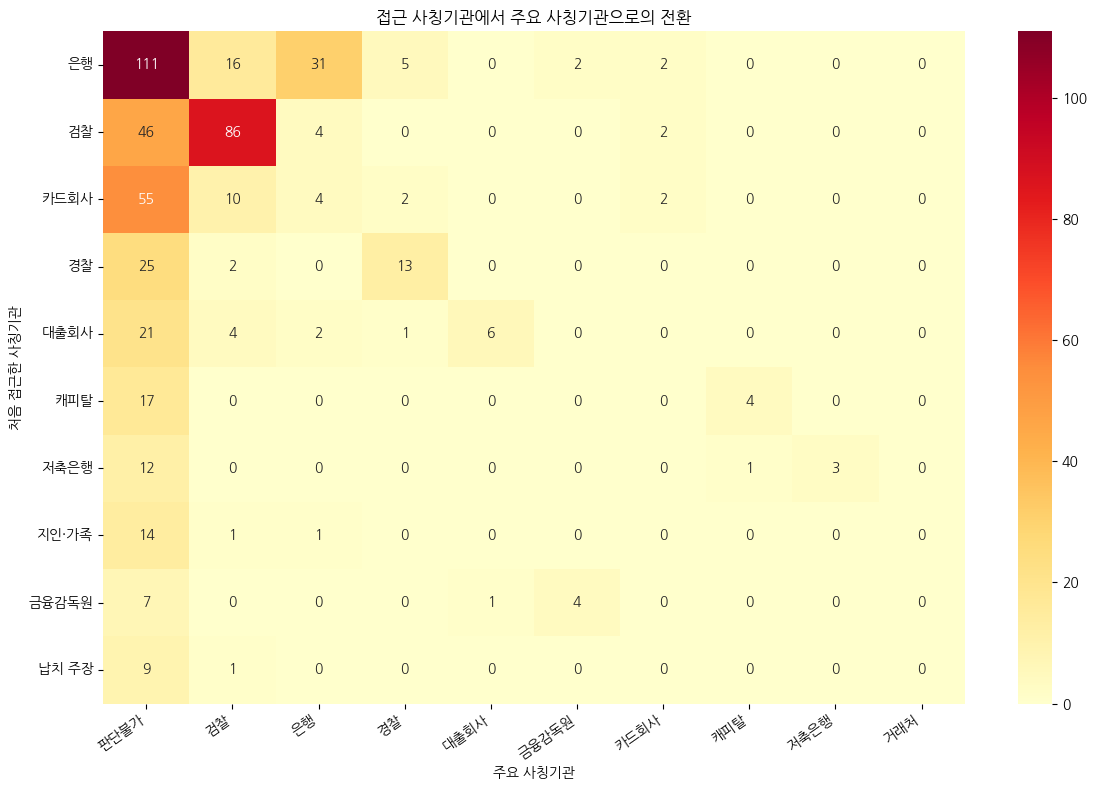

,사기유형,전체사건수,판단불가사건수,다중사칭사건수,검수필요사건수,판단불가비율,다중사칭비율,검수필요비율
0,대출사기형,187,146,100,156,78.074866,53.475936,83.42246
1,수사기관 사칭형,190,94,114,133,49.473684,60.000000,70.00000


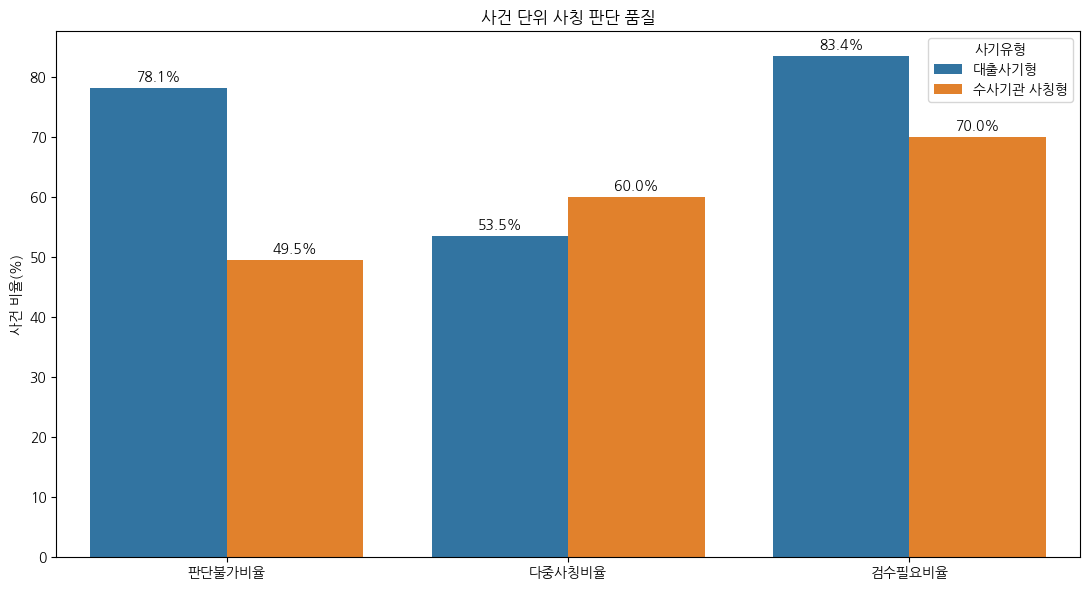

사건 단위 사칭 대상 그래프 4개 저장 완료


In [28]:
# 사건 단위 사칭 대상 그래프

impersonation_name_map = {
    'BANK': '은행',
    'BUSINESS_CONTACT': '거래처',
    'CAPITAL_COMPANY': '캐피탈',
    'CARD_COMPANY': '카드회사',
    'COURT': '법원',
    'DELIVERY_COMPANY': '택배회사',
    'FINANCIAL_ASSOCIATION': '금융협회',
    'FSS': '금융감독원',
    'KIDNAPPING_CLAIM': '납치 주장',
    'LOAN_COMPANY': '대출회사',
    'PERSONAL_CONTACT': '지인·가족',
    'POLICE': '경찰',
    'POST_OFFICE': '우체국',
    'PROSECUTION': '검찰',
    'RECRUITER': '채용담당자',
    'SAVINGS_BANK': '저축은행',
    'TAX_AUTHORITY': '세무기관',
    'TELECOM': '통신회사',
    'UNKNOWN': '판단불가'
}

fraud_type_name_map = {
    'INSTITUTION_IMPERSONATION': '수사기관 사칭형',
    'LOAN_FRAUD': '대출사기형'
}

plot_case_df = case_impersonation_df.copy()

plot_case_df['사기유형'] = (
    plot_case_df['supervised_target']
    .map(fraud_type_name_map)
    .fillna(plot_case_df['supervised_target'])
)

plot_case_df['주요사칭기관'] = (
    plot_case_df['자동_주요사칭기관']
    .map(impersonation_name_map)
    .fillna(plot_case_df['자동_주요사칭기관'])
)

plot_case_df['접근사칭기관_한글'] = (
    plot_case_df['접근사칭기관']
    .map(impersonation_name_map)
    .fillna(plot_case_df['접근사칭기관'])
)


# 1. 사기유형별 주요 사칭기관 사건 비율
primary_ratio_df = pd.crosstab(
    plot_case_df['사기유형'],
    plot_case_df['주요사칭기관'],
    normalize='index'
) * 100

primary_count_df = pd.crosstab(
    plot_case_df['사기유형'],
    plot_case_df['주요사칭기관']
)

display(primary_count_df)
display(primary_ratio_df.round(1))

primary_count_df.to_csv(
    TABLE_ROOT / '사건단위_주요사칭기관_건수.csv',
    encoding='utf-8-sig'
)

primary_ratio_df.to_csv(
    TABLE_ROOT / '사건단위_주요사칭기관_비율.csv',
    encoding='utf-8-sig'
)

# 전체 사건에서 많이 등장한 상위 기관만 표시
top_institutions = (
    primary_count_df
    .sum(axis=0)
    .nlargest(10)
    .index
)

bar_df = (
    primary_ratio_df[top_institutions]
    .reset_index()
    .melt(
        id_vars='사기유형',
        var_name='주요사칭기관',
        value_name='사건비율'
    )
)

plt.figure(figsize=(15, 7))

ax = sns.barplot(
    data=bar_df,
    x='주요사칭기관',
    y='사건비율',
    hue='사기유형',
    palette=['#4c72b0', '#dd8452']
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3,
        fontsize=8
    )

plt.title('보이스피싱 유형별 사건 단위 주요 사칭기관')
plt.xlabel('주요 사칭기관')
plt.ylabel('해당 유형 내 사건 비율(%)')
plt.xticks(rotation=25)
plt.legend(title='사기유형')
plt.tight_layout()

plt.savefig(
    FIGURE_ROOT / '사건단위_주요사칭기관_막대그래프.png',
    dpi=170,
    bbox_inches='tight'
)

plt.show()


# 2. 주요 사칭기관 비율 히트맵
plt.figure(figsize=(15, 5))

sns.heatmap(
    primary_ratio_df,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    cbar_kws={
        'label': '해당 유형 내 사건 비율(%)'
    }
)

plt.title('보이스피싱 유형별 사건 단위 주요 사칭기관')
plt.xlabel('주요 사칭기관')
plt.ylabel('사기유형')
plt.xticks(rotation=40, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(
    FIGURE_ROOT / '사건단위_주요사칭기관_히트맵.png',
    dpi=170,
    bbox_inches='tight'
)

plt.show()


# 3. 접근 사칭기관 → 주요 사칭기관 전환
transition_count_df = pd.crosstab(
    plot_case_df['접근사칭기관_한글'],
    plot_case_df['주요사칭기관']
)

# 너무 드문 기관을 제외하고 상위 기관만 표시
top_access = (
    transition_count_df
    .sum(axis=1)
    .nlargest(10)
    .index
)

top_primary = (
    transition_count_df
    .sum(axis=0)
    .nlargest(10)
    .index
)

transition_plot_df = transition_count_df.loc[
    top_access,
    top_primary
]

display(transition_plot_df)

transition_count_df.to_csv(
    TABLE_ROOT / '사건단위_접근기관_주요기관_전환표.csv',
    encoding='utf-8-sig'
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    transition_plot_df,
    annot=True,
    fmt='g',
    cmap='YlOrRd'
)

plt.title('접근 사칭기관에서 주요 사칭기관으로의 전환')
plt.xlabel('주요 사칭기관')
plt.ylabel('처음 접근한 사칭기관')
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(
    FIGURE_ROOT / '사건단위_사칭기관_전환히트맵.png',
    dpi=170,
    bbox_inches='tight'
)

plt.show()


# 4. 판단불가·다중 사칭 사건 비율
quality_plot_df = (
    plot_case_df
    .groupby('사기유형')
    .agg(
        전체사건수=('case_id', 'nunique'),
        판단불가사건수=(
            '자동_주요사칭기관',
            lambda values: values.eq('UNKNOWN').sum()
        ),
        다중사칭사건수=(
            '다중사칭여부',
            'sum'
        ),
        검수필요사건수=(
            '검수필요여부',
            'sum'
        )
    )
    .reset_index()
)

for column in [
    '판단불가사건수',
    '다중사칭사건수',
    '검수필요사건수'
]:
    quality_plot_df[
        column.replace('사건수', '비율')
    ] = (
        quality_plot_df[column]
        / quality_plot_df['전체사건수']
        * 100
    )

display(quality_plot_df)

quality_plot_df.to_csv(
    TABLE_ROOT / '사건단위_사칭판단_품질요약.csv',
    index=False,
    encoding='utf-8-sig'
)

quality_long_df = quality_plot_df.melt(
    id_vars='사기유형',
    value_vars=[
        '판단불가비율',
        '다중사칭비율',
        '검수필요비율'
    ],
    var_name='구분',
    value_name='사건비율'
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=quality_long_df,
    x='구분',
    y='사건비율',
    hue='사기유형'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3
    )

plt.title('사건 단위 사칭 판단 품질')
plt.xlabel('')
plt.ylabel('사건 비율(%)')
plt.legend(title='사기유형')
plt.tight_layout()

plt.savefig(
    FIGURE_ROOT / '사건단위_사칭판단_품질그래프.png',
    dpi=170,
    bbox_inches='tight'
)

plt.show()

print('사건 단위 사칭 대상 그래프 4개 저장 완료')

## 6. 심리전략 빈도·조합·사건 흐름

,strategy_type,건수,비율
0,URGENCY_TIME_PRESSURE,2435,0.315496
1,AUTHORITY_TRUST,1886,0.244364
2,FEAR_THREAT,1230,0.159368
3,MONEY_REQUEST,1113,0.144208
4,LEGITIMACY_BUILDING,409,0.052993
5,BENEFIT_PROMISE,278,0.036020
6,INFORMATION_EXTRACTION,213,0.027598
7,RESISTANCE_HANDLING,69,0.008940
8,ISOLATION_SECRECY,46,0.005960
9,BEHAVIOR_CONTROL,39,0.005053


strategy_type,AUTHORITY_TRUST,BEHAVIOR_CONTROL,BENEFIT_PROMISE,FEAR_THREAT,INFORMATION_EXTRACTION,ISOLATION_SECRECY,LEGITIMACY_BUILDING,MONEY_REQUEST,RESISTANCE_HANDLING,URGENCY_TIME_PRESSURE
supervised_target,,,,,,,,,,
INSTITUTION_IMPERSONATION,816,13,3,681,71,12,172,180,16,882
LOAN_FRAUD,555,19,260,27,69,18,74,734,30,1046


strategy_type,AUTHORITY_TRUST,BEHAVIOR_CONTROL,BENEFIT_PROMISE,FEAR_THREAT,INFORMATION_EXTRACTION,ISOLATION_SECRECY,LEGITIMACY_BUILDING,MONEY_REQUEST,RESISTANCE_HANDLING,URGENCY_TIME_PRESSURE
supervised_target,,,,,,,,,,
INSTITUTION_IMPERSONATION,0.2867,0.0046,0.0011,0.2393,0.0249,0.0042,0.0604,0.0632,0.0056,0.3099
LOAN_FRAUD,0.1960,0.0067,0.0918,0.0095,0.0244,0.0064,0.0261,0.2592,0.0106,0.3694


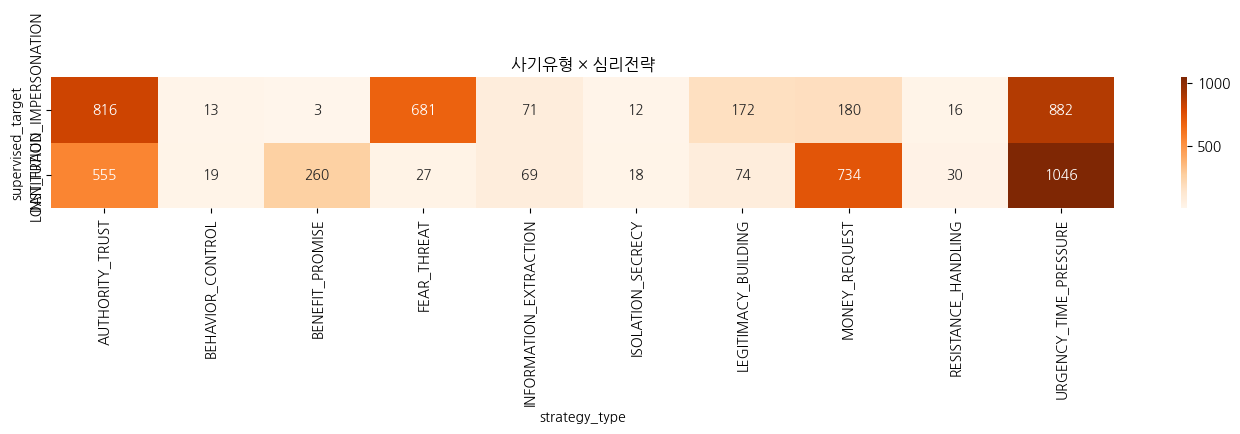

In [12]:
# 11. 전략 분포와 사기유형별 전략
strategy=tables['vp_strategy_events']; strategy_col='strategy_type'
strategy_count=save_count(strategy,strategy_col,'14_심리전략_분포',TOP_N)
strategy_cross=event_crosstab(strategy,strategy_col,'15_사기유형_심리전략')
if not strategy_cross.empty:
    plt.figure(figsize=(14,4)); sns.heatmap(strategy_cross,annot=True,fmt='g',cmap='Oranges')
    plt.title('사기유형 × 심리전략'); plt.tight_layout(); plt.savefig(FIGURE_ROOT/'04_사기유형_심리전략.png',dpi=170); plt.show()

strategy_type,AUTHORITY_TRUST,BEHAVIOR_CONTROL,BENEFIT_PROMISE,FEAR_THREAT,INFORMATION_EXTRACTION,ISOLATION_SECRECY,LEGITIMACY_BUILDING,MONEY_REQUEST,RESISTANCE_HANDLING,URGENCY_TIME_PRESSURE
strategy_type,,,,,,,,,,
AUTHORITY_TRUST,489,22,65,266,123,26,134,235,44,382
BEHAVIOR_CONTROL,22,27,3,12,3,1,8,15,2,24
BENEFIT_PROMISE,65,3,100,13,18,7,20,76,7,85
FEAR_THREAT,266,12,13,306,89,11,114,126,29,242
INFORMATION_EXTRACTION,123,3,18,89,139,21,51,73,18,119
ISOLATION_SECRECY,26,1,7,11,21,33,7,18,2,29
LEGITIMACY_BUILDING,134,8,20,114,51,7,163,78,17,146
MONEY_REQUEST,235,15,76,126,73,18,78,306,32,268
RESISTANCE_HANDLING,44,2,7,29,18,2,17,32,52,45


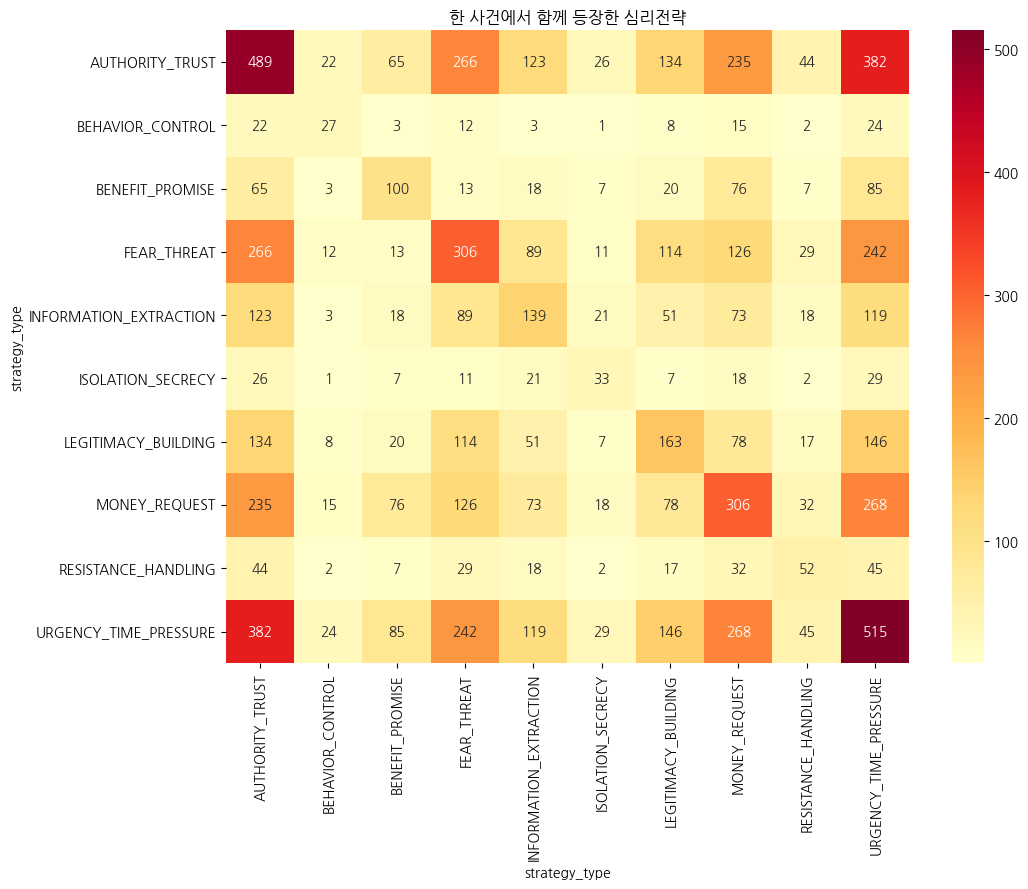

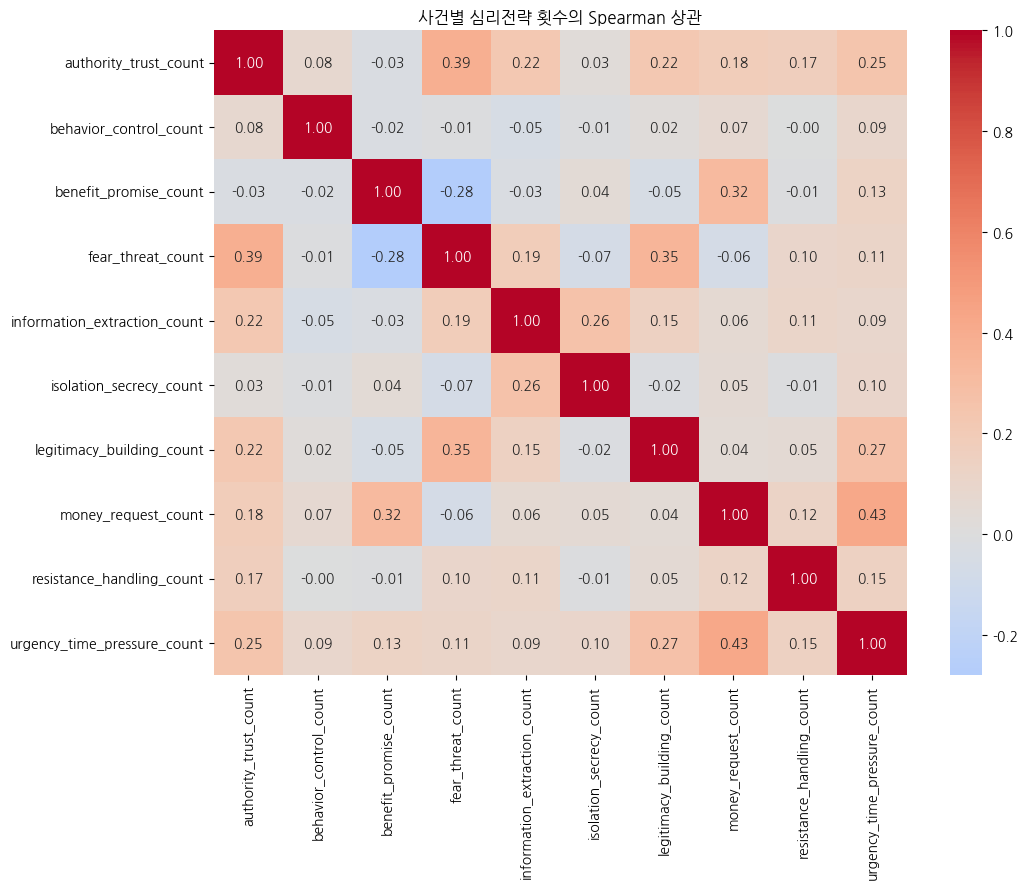

In [13]:
# 12. 한 사건에서 함께 등장한 심리전략
strategy_binary=pd.crosstab(strategy['case_id'],strategy[strategy_col]).gt(0).astype(int)
cooccur=strategy_binary.T.dot(strategy_binary)
cooccur.to_csv(TABLE_ROOT/'16_심리전략_동시출현.csv',encoding='utf-8-sig')
display(cooccur)
plt.figure(figsize=(11,9)); sns.heatmap(cooccur,annot=True,fmt='g',cmap='YlOrRd')
plt.title('한 사건에서 함께 등장한 심리전략'); plt.tight_layout()
plt.savefig(FIGURE_ROOT/'05_심리전략_동시출현.png',dpi=170); plt.show()
dashboard=tables['dashboard_case_summary']
strategy_cols=[c for c in dashboard.columns if c.endswith('_count') and any(k in c for k in ['authority','behavior','benefit','fear','information','isolation','legitimacy','money','resistance','urgency'])]
if strategy_cols:
    corr=dashboard[strategy_cols].apply(pd.to_numeric,errors='coerce').corr(method='spearman')
    corr.to_csv(TABLE_ROOT/'17_심리전략_상관계수.csv',encoding='utf-8-sig')
    plt.figure(figsize=(11,9)); sns.heatmap(corr,annot=True,fmt='.2f',center=0,cmap='coolwarm')
    plt.title('사건별 심리전략 횟수의 Spearman 상관'); plt.tight_layout()
    plt.savefig(FIGURE_ROOT/'06_심리전략_상관.png',dpi=170); plt.show()

## 7. 금액 방향·용도·품질 분석

In [14]:
# 13. 금액 상태·방향·용도 교차분석
amount=tables['vp_amount_events'].copy()
amount['amount_krw']=pd.to_numeric(amount['amount_krw'],errors='coerce')
amount['amount_10k_krw']=amount['amount_krw']/10000
status_direction=pd.crosstab(amount['amount_status'],amount['amount_direction'],margins=True)
direction_purpose=pd.crosstab(amount['amount_direction'],amount['amount_purpose'],margins=True)
display(status_direction); display(direction_purpose)
status_direction.to_csv(TABLE_ROOT/'18_금액상태_방향_교차표.csv',encoding='utf-8-sig')
direction_purpose.to_csv(TABLE_ROOT/'19_금액방향_용도_교차표.csv',encoding='utf-8-sig')
unknown_summary=pd.DataFrame([
 {'항목':'금액방향 미분류','건수':int(amount.amount_direction.eq('NO_DIRECTION').sum()),'비율':amount.amount_direction.eq('NO_DIRECTION').mean()},
 {'항목':'금액용도 미분류','건수':int(amount.amount_purpose.eq('UNKNOWN').sum()),'비율':amount.amount_purpose.eq('UNKNOWN').mean()}])
display(unknown_summary); unknown_summary.to_csv(TABLE_ROOT/'20_금액라벨_미분류율.csv',index=False,encoding='utf-8-sig')
direction_amount=amount.groupby('amount_direction')['amount_10k_krw'].agg(['count','median','mean','min','max']).round(2)
purpose_amount=amount.groupby('amount_purpose')['amount_10k_krw'].agg(['count','median','mean','min','max']).round(2)
display(direction_amount); display(purpose_amount)
direction_amount.to_csv(TABLE_ROOT/'21_금액방향별_금액만원.csv',encoding='utf-8-sig')
purpose_amount.to_csv(TABLE_ROOT/'22_금액용도별_금액만원.csv',encoding='utf-8-sig')

amount_direction,NO_DIRECTION,OFFERED_TO_VICTIM,REQUESTED_FROM_VICTIM,All
amount_status,,,,
MENTIONED,727,16,9,752
REQUESTED,0,1,0,1
All,727,17,9,753


amount_purpose,ACCOUNT_BALANCE,FEE,LOAN_PRINCIPAL,REFUND,SECURITY_DEPOSIT,TAX,UNKNOWN,All
amount_direction,,,,,,,,
NO_DIRECTION,21,6,69,21,2,17,591,727
OFFERED_TO_VICTIM,0,0,2,5,0,1,9,17
REQUESTED_FROM_VICTIM,0,4,3,0,0,1,1,9
All,21,10,74,26,2,19,601,753


,항목,건수,비율
0,금액방향 미분류,727,0.965471
1,금액용도 미분류,601,0.798141


,count,median,mean,min,max
amount_direction,,,,,
NO_DIRECTION,727,300.0,1555.11,0.00,200000.0
OFFERED_TO_VICTIM,17,600.0,1235.29,100.00,5000.0
REQUESTED_FROM_VICTIM,9,600.0,1100.05,0.44,3000.0


,count,median,mean,min,max
amount_purpose,,,,,
ACCOUNT_BALANCE,21,3000.00,3107.62,10.00,8600.00
FEE,10,83.00,349.98,0.20,1500.00
LOAN_PRINCIPAL,74,600.00,1807.05,0.85,9800.00
REFUND,26,95.00,607.95,0.20,8000.00
SECURITY_DEPOSIT,2,0.15,0.15,0.06,0.25
TAX,19,90.00,248.02,0.20,2700.00
UNKNOWN,601,300.00,1561.50,0.00,200000.00


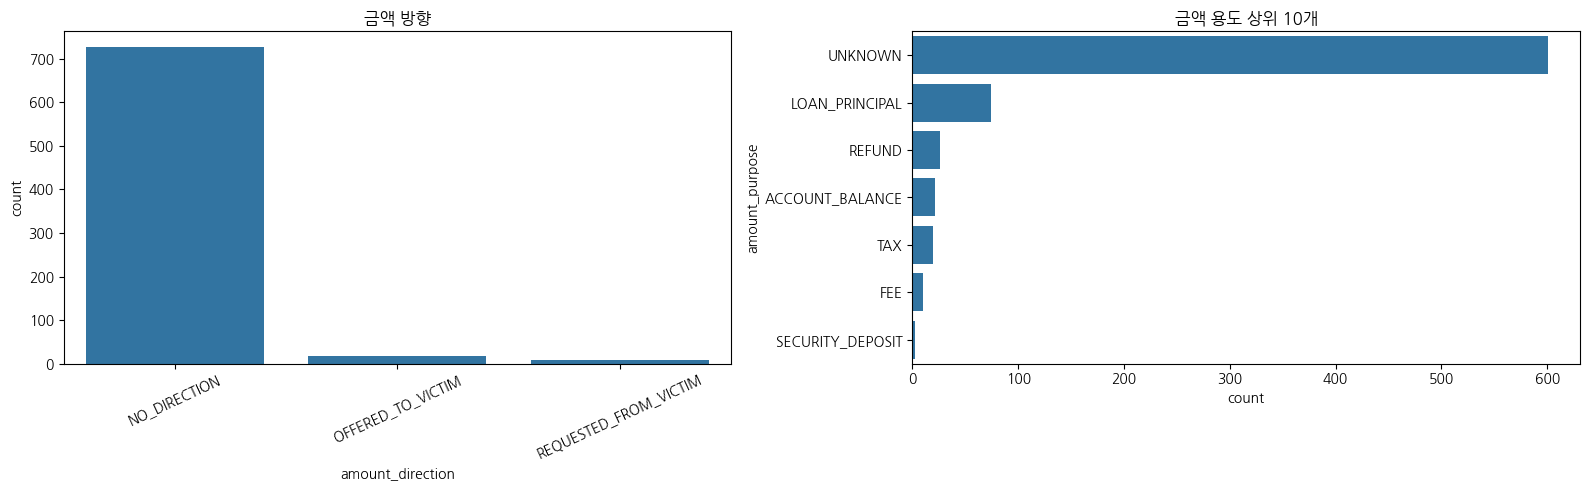

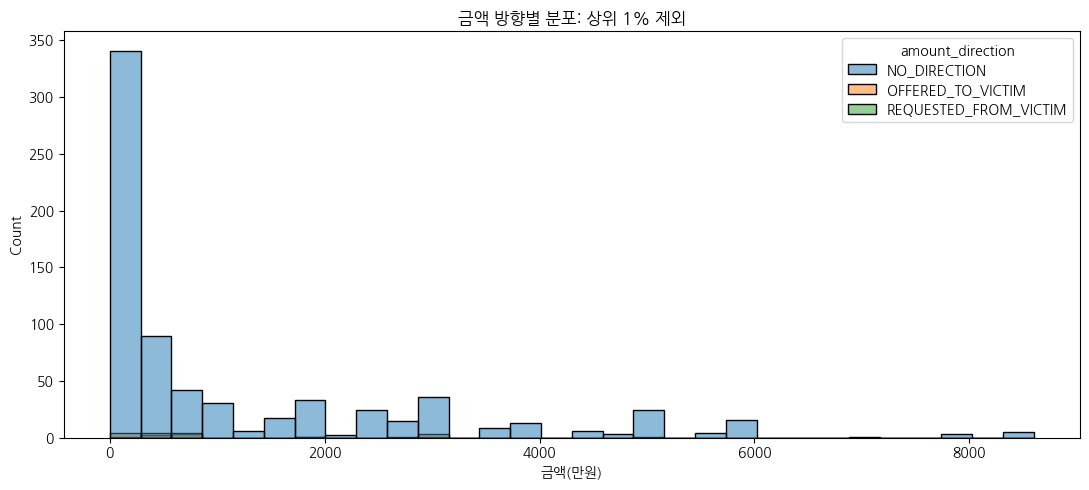

,amount_event_id,case_id,amount_krw,amount_status,amount_direction,amount_purpose,evidence_role,evidence_text,amount_direction_evidence,amount_direction_confidence
108,amt_448e00188d2c,vp_36519_case_001,1000000.0,REQUESTED,OFFERED_TO_VICTIM,TAX,OFFENDER,네. 네. 오늘 이제 납부 처리 가능하세요? 변제? 네. 네. 아 세람에 이제 10...,네. 네. 오늘 이제 납부 처리 가능하세요? 변제? 네. 네. 아 세람에 이제 10...,0.80
142,amt_314d5eb0cc40,vp_36583_case_001,6000000.0,MENTIONED,REQUESTED_FROM_VICTIM,FEE,OFFENDER,x림을 불러가지고 수수료 600만원 드리고 사인을 할겁니다.,x림을 불러가지고 수수료 600만원 드리고 사인을 할겁니다.,0.65
143,amt_5f8ef95e743f,vp_36583_case_001,6000000.0,MENTIONED,REQUESTED_FROM_VICTIM,FEE,OFFENDER,차량 가격의 10% 수수료 600만원을 수용을 하셨지 않습니까?,차량 가격의 10% 수수료 600만원을 수용을 하셨지 않습니까?,0.65
144,amt_aa285e35c06a,vp_36583_case_002,6000000.0,MENTIONED,REQUESTED_FROM_VICTIM,FEE,OFFENDER,그 수수료 600만원까지 같이 보내기 때문에,그 수수료 600만원까지 같이 보내기 때문에,0.65
188,amt_509cd661442b,vp_36602_case_001,4400.0,MENTIONED,REQUESTED_FROM_VICTIM,FEE,OFFENDER,"범용으로 재발행이 들어가실 때는 고객님 4,400원 수수료가 부과가 되세요","범용으로 재발행이 들어가실 때는 고객님 4,400원 수수료가 부과가 되세요",0.65
327,amt_d2c2d36489cf,vp_36676_case_001,30000000.0,MENTIONED,REQUESTED_FROM_VICTIM,UNKNOWN,OFFENDER,네. 저희한테 보내주셨던 이 계좌로 이제 저희 쪽 자금 3천만 원 송금해드리면 되는...,네. 저희한테 보내주셨던 이 계좌로 이제 저희 쪽 자금 3천만 원 송금해드리면 되는...,0.65
368,amt_56900bd823f9,vp_36688_case_001,3000000.0,MENTIONED,REQUESTED_FROM_VICTIM,LOAN_PRINCIPAL,OFFENDER,그냥 300만 원 이거 완납 서류를 좀 보내주시겠어요? 그리고 300만 원 하고 그...,그냥 300만 원 이거 완납 서류를 좀 보내주시겠어요? 그리고 300만 원 하고 그...,0.65
369,amt_06238f5d33ac,vp_36688_case_001,3000000.0,MENTIONED,REQUESTED_FROM_VICTIM,LOAN_PRINCIPAL,OFFENDER,그냥 300만 원 이거 완납 서류를 좀 보내주시겠어요? 그리고 300만 원 하고 그...,그냥 300만 원 이거 완납 서류를 좀 보내주시겠어요? 그리고 300만 원 하고 그...,0.65
370,amt_066783f07a0e,vp_36688_case_001,18000000.0,MENTIONED,REQUESTED_FROM_VICTIM,LOAN_PRINCIPAL,OFFENDER,그냥 300만 원 이거 완납 서류를 좀 보내주시겠어요? 그리고 300만 원 하고 그...,그냥 300만 원 이거 완납 서류를 좀 보내주시겠어요? 그리고 300만 원 하고 그...,0.65
387,amt_b66a041a9cf7,vp_36695_case_002,27000000.0,MENTIONED,REQUESTED_FROM_VICTIM,TAX,OFFENDER,한 번에 이걸 2700만 원 납부해주셔야 됩니다.,한 번에 이걸 2700만 원 납부해주셔야 됩니다.,0.65


In [15]:
# 14. 금액 그래프와 충돌·검토 대상
fig,axes=plt.subplots(1,2,figsize=(16,5))
sns.countplot(data=amount,x='amount_direction',order=amount.amount_direction.value_counts().index,ax=axes[0]); axes[0].tick_params(axis='x',rotation=25); axes[0].set_title('금액 방향')
top_purpose=amount.amount_purpose.value_counts().head(10).index
sns.countplot(data=amount[amount.amount_purpose.isin(top_purpose)],y='amount_purpose',order=top_purpose,ax=axes[1]); axes[1].set_title('금액 용도 상위 10개')
plt.tight_layout(); plt.savefig(FIGURE_ROOT/'07_금액방향_용도.png',dpi=170); plt.show()
upper=amount.amount_10k_krw.quantile(.99); plot_amount=amount[amount.amount_10k_krw.between(0,upper)]
plt.figure(figsize=(11,5)); sns.histplot(data=plot_amount,x='amount_10k_krw',hue='amount_direction',bins=30)
plt.xlabel('금액(만원)'); plt.title('금액 방향별 분포: 상위 1% 제외'); plt.tight_layout()
plt.savefig(FIGURE_ROOT/'08_금액방향별_만원분포.png',dpi=170); plt.show()
conflict_mask=(amount.amount_status.eq('REQUESTED') & ~amount.amount_direction.eq('REQUESTED_FROM_VICTIM')) | (amount.amount_direction.eq('REQUESTED_FROM_VICTIM') & ~amount.amount_status.eq('REQUESTED'))
review_cols=[c for c in ['amount_event_id','case_id','amount_krw','amount_status','amount_direction','amount_purpose','evidence_role','evidence_text','amount_direction_evidence','amount_direction_confidence'] if c in amount]
amount_conflicts=amount.loc[conflict_mask,review_cols].copy()
display(amount_conflicts.head(30)); amount_conflicts.to_csv(REVIEW_ROOT/'금액라벨_충돌_검토대상.csv',index=False,encoding='utf-8-sig')

## 8. 전체·부분 구간 분석

,sample_scope,window_position,fraud_label,건수,텍스트길이_중앙값,텍스트길이_평균
0,FULL,FULL,LEGITIMATE_FINANCIAL_CALL,2151,1626.0,1676.197583
1,FULL,FULL,VOICE_PHISHING,717,612.0,916.856346
2,WINDOW,EARLY,LEGITIMATE_FINANCIAL_CALL,14850,257.0,296.136498
3,WINDOW,EARLY,VOICE_PHISHING,6788,113.0,138.846494
4,WINDOW,LATE,LEGITIMATE_FINANCIAL_CALL,15857,268.0,311.404175
5,WINDOW,LATE,VOICE_PHISHING,7043,97.0,115.630413
6,WINDOW,MIDDLE,LEGITIMATE_FINANCIAL_CALL,17607,271.0,317.491566
7,WINDOW,MIDDLE,VOICE_PHISHING,7699,104.0,125.777633


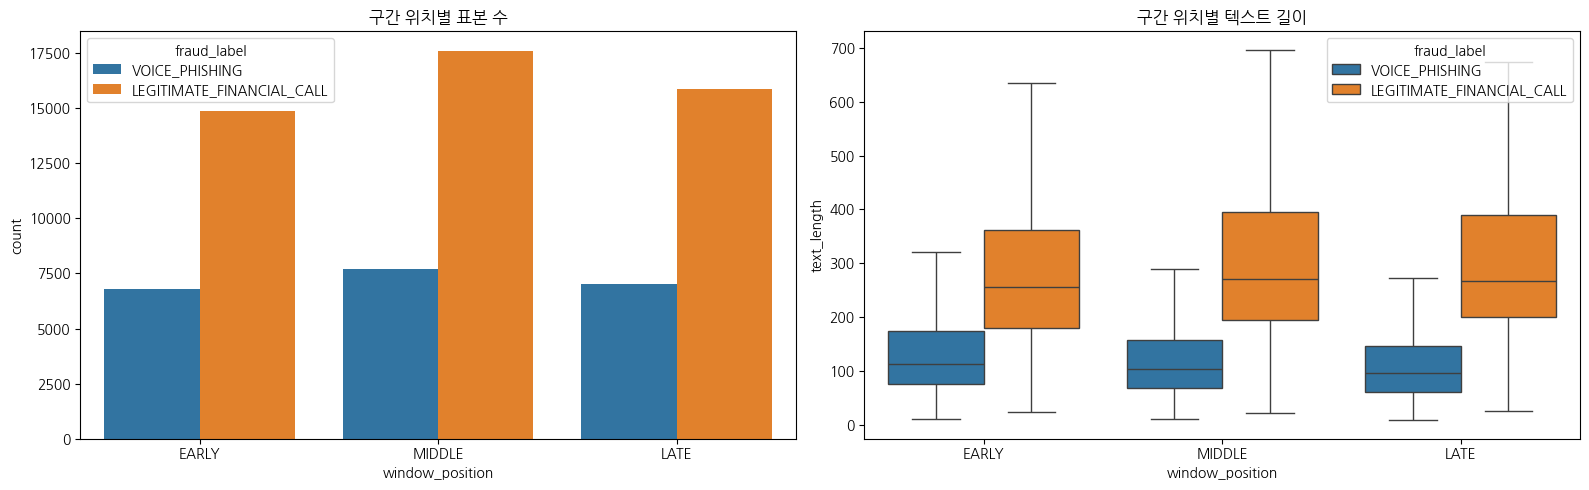

In [16]:
# 15. 앞·중간·뒤·전체 구간의 표본과 길이
segment=tables['segment_detection_ml'].copy()
segment['text_length']=segment['window_text'].fillna('').str.len()
segment_summary=segment.groupby(['sample_scope','window_position','fraud_label']).agg(건수=('window_text','size'),텍스트길이_중앙값=('text_length','median'),텍스트길이_평균=('text_length','mean')).reset_index()
display(segment_summary); segment_summary.to_csv(TABLE_ROOT/'23_전체부분구간_분포.csv',index=False,encoding='utf-8-sig')
window=segment[segment.sample_scope.eq('WINDOW')]
fig,axes=plt.subplots(1,2,figsize=(16,5))
sns.countplot(data=window,x='window_position',hue='fraud_label',ax=axes[0]); axes[0].set_title('구간 위치별 표본 수')
sns.boxplot(data=window,x='window_position',y='text_length',hue='fraud_label',showfliers=False,ax=axes[1]); axes[1].set_title('구간 위치별 텍스트 길이')
plt.tight_layout(); plt.savefig(FIGURE_ROOT/'09_전체부분구간_분포.png',dpi=170); plt.show()

## 9. 사건 길이·발화·최초 위험행동

,count,mean,std,min,25%,50%,75%,90%,95%,max
duration_sec,776.0,127.27,127.12,0.0,47.57,87.63,164.72,275.46,358.97,1129.40
turn_count,776.0,42.31,54.60,0.0,10.00,26.00,54.00,98.00,127.00,622.00
speaker_count,776.0,2.10,0.82,0.0,2.00,2.00,2.00,3.00,4.00,5.00
offender_turn_count,776.0,27.07,37.72,0.0,3.00,16.00,35.00,66.00,87.25,368.00
victim_turn_count,776.0,7.66,16.88,0.0,0.00,0.00,10.00,22.00,32.50,254.00
unknown_turn_count,776.0,7.58,18.87,0.0,0.00,0.00,8.00,23.00,35.25,247.00
requested_action_count,776.0,0.60,1.05,0.0,0.00,0.00,1.00,2.00,3.00,7.00
strategy_diversity,776.0,2.74,1.81,0.0,1.00,3.00,4.00,5.00,6.00,7.00
first_risky_action_sec,270.0,191.72,280.66,0.0,44.03,102.00,206.46,437.92,698.46,2301.12


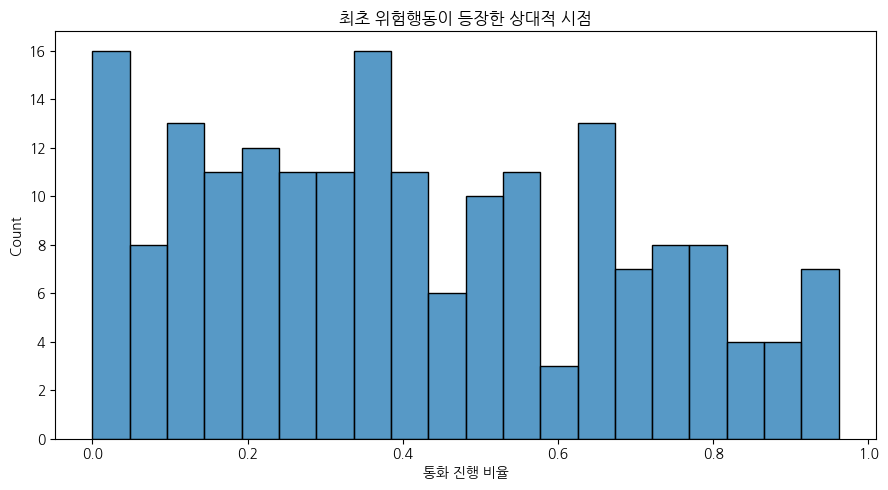

In [17]:
# 16. 사건 단위 기술통계: 발화 비율은 대화 주도권의 확정값이 아닙니다.
case_source=dashboard if not dashboard.empty else cases
numeric_cols=[c for c in ['duration_sec','turn_count','speaker_count','offender_turn_count','victim_turn_count','unknown_turn_count','requested_action_count','strategy_diversity','first_risky_action_sec'] if c in case_source]
case_stats=case_source[numeric_cols].apply(pd.to_numeric,errors='coerce').describe(percentiles=[.25,.5,.75,.9,.95]).T.round(2) if numeric_cols else pd.DataFrame()
display(case_stats); case_stats.to_csv(TABLE_ROOT/'24_사건단위_기술통계.csv',encoding='utf-8-sig')
if {'first_risky_action_sec','duration_sec'}.issubset(case_source.columns):
    timing=case_source[['case_id','first_risky_action_sec','duration_sec']].copy()
    timing['최초위험행동_진행비율']=pd.to_numeric(timing.first_risky_action_sec,errors='coerce')/pd.to_numeric(timing.duration_sec,errors='coerce').replace(0,np.nan)
    timing=timing[timing['최초위험행동_진행비율'].between(0,1)]
    timing.to_csv(TABLE_ROOT/'25_최초위험행동_진행비율.csv',index=False,encoding='utf-8-sig')
    plt.figure(figsize=(9,5)); sns.histplot(timing['최초위험행동_진행비율'],bins=20)
    plt.xlabel('통화 진행 비율'); plt.title('최초 위험행동이 등장한 상대적 시점'); plt.tight_layout()
    plt.savefig(FIGURE_ROOT/'10_최초위험행동_시점.png',dpi=170); plt.show()

## 10. 최종 요약과 보고서 저장

In [18]:
# 17. EDA 자동 요약
total_amount=len(amount); no_direction=int(amount.amount_direction.eq('NO_DIRECTION').sum()); unknown_purpose=int(amount.amount_purpose.eq('UNKNOWN').sum())
class_counts=det.fraud_label.value_counts().to_dict()
median_lengths=det.groupby('fraud_label').text_length.median().to_dict()
report=[
 '# 03-2 EDA 결과 요약','', '## 데이터 규모','',
 f"- 정상상담: {class_counts.get('LEGITIMATE_FINANCIAL_CALL',0):,}건",
 f"- 보이스피싱: {class_counts.get('VOICE_PHISHING',0):,}건",
 f"- 정상상담 텍스트 길이 중앙값: {median_lengths.get('LEGITIMATE_FINANCIAL_CALL',np.nan):,.0f}자",
 f"- 보이스피싱 텍스트 길이 중앙값: {median_lengths.get('VOICE_PHISHING',np.nan):,.0f}자",'',
 '## 주요 품질 이슈','',
 '- 정상상담과 보이스피싱은 출처와 원본 편집 방식이 달라 길이·문체 편향을 확인해야 합니다.',
 f'- 금액 방향 미분류: {no_direction:,}/{total_amount:,}건 ({no_direction/max(total_amount,1):.1%})',
 f'- 금액 용도 미분류: {unknown_purpose:,}/{total_amount:,}건 ({unknown_purpose/max(total_amount,1):.1%})',
 f'- 금액 상태·방향 충돌 검토 대상: {len(amount_conflicts):,}건','',
 '## 해석 기준','',
 '- 사칭·행동·전략·금액은 규칙 기반 SILVER 라벨이므로 탐색적 경향으로 해석합니다.',
 '- 건수와 함께 행 비율을 사용하며, 금액은 평균보다 중앙값을 우선 확인합니다.',
 '- 발화 수 차이는 대화 주도권의 확정 증거가 아닙니다.',
 '- 실제 피해 여부 정답이 없으므로 피해 발생 확률로 해석하지 않습니다.'
]
(REPORT_ROOT/'03_2_eda_report.md').write_text('\n'.join(report),encoding='utf-8')
manifest={'version':'03-2_v1','dataset_root':str(DATASET_ROOT),'output_root':str(OUTPUT_ROOT),
          'tables':inventory.to_dict(orient='records'),'saved_csv':len(list(TABLE_ROOT.glob('*.csv'))),
          'saved_figures':len(list(FIGURE_ROOT.glob('*.png'))),'amount_conflict_rows':len(amount_conflicts)}
(REPORT_ROOT/'03_2_eda_manifest.json').write_text(json.dumps(manifest,ensure_ascii=False,indent=2,default=str),encoding='utf-8')
print('분석표:',len(list(TABLE_ROOT.glob('*.csv'))),'개')
print('그래프:',len(list(FIGURE_ROOT.glob('*.png'))),'개')
print('03-2 EDA 정상 완료:',OUTPUT_ROOT)

분석표: 31 개
그래프: 10 개
03-2 EDA 정상 완료: /content/drive/MyDrive/보이스피싱_분석/EDA_분석결과_v1
